# 1. Project Configuration

Bagian ini mendefinisikan konfigurasi utama penelitian: struktur folder Google Drive, kelas SATB, variasi rekaman, parameter audio, parameter MFCC, parameter augmentasi, dan parameter pelatihan CNN. Notebook ini dirancang agar dapat dijalankan dari atas ke bawah tanpa mengubah kode secara manual.


In [29]:
import os, random
import numpy as np
import tensorflow as tf
from pathlib import Path

# ============================================================
# FINAL CONFIG - SATB CNN + HYBRID FEATURES + SPECAUGMENT
# ============================================================

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except:
    pass

CONFIG = {
    # Project
    "project_name": "SATB CNN Hybrid Features",
    "drive_project_dir": Path("/content/drive/MyDrive/SATB_Model"),
    "local_fallback_dir": Path("/content/SATB_Model"),

    # Classes
    "classes": ["Soprano", "Alto", "Tenor", "Bass"],

    # Dataset
    "internal_variations": ["R1","R2","R3","R4","R5","R6","R7"],
    "external_variations": ["R1","R2","R3"],
    "secondary_variations": ["R1","R2","R3"],
    "secondary_folder_name": "Sekunder",

    # Audio
    "supported_extensions": [".wav",".mp3",".m4a",".ogg",".aac",".mp4"],
    "sample_rate": 16000,
    "mono": True,
    "pcm_subtype": "PCM_16",

    # Preprocessing
    "silence_gap_ms": 400,
    "trim_top_db": 25,

    # Split
    "random_seed": SEED,
    "train_ratio": 0.70,
    "validation_ratio": 0.15,
    "test_ratio": 0.15,

    # MFCC
    "n_mfcc": 40,
    "n_fft": 2048,
    "hop_length": 512,
    "window": "hann",
    "max_target_frames": 700,

    # Chroma
    "n_chroma": 12,

    # Hybrid Features
    "hybrid_features": [
        "MFCC",
        "Delta MFCC",
        "Delta-Delta MFCC",
        "Chroma STFT"
    ],
    "input_channels": 4,

    # SpecAugment - feature level only
    "use_specaugment": True,
    "freq_mask_max_width": 3,
    "time_mask_max_width": 25,
    "num_freq_masks": 1,
    "num_time_masks": 1,

    # CNN Training
    "learning_rate": 0.005,
    "epochs": 100,
    "batch_size": 32,
    "patience": 10,
    "clipnorm": 1.0,
    "label_smoothing": 0.05,

    # CNN Architecture
    "conv_filters": [32, 64, 128],
    "kernel_size": (3,3),
    "l2": 0.0001,
    "spatial_dropout": [0.15, 0.20, 0.25],
    "dense_units": 64,
    "dense_dropout": 0.30,

    # Callbacks
    "reduce_lr_factor": 0.5,
    "reduce_lr_patience": 3,
    "restore_best_weights": True,
}

print("=" * 60)
print("FINAL SATB CNN CONFIG")
print("=" * 60)
print("Classes        :", CONFIG["classes"])
print("Random Seed    :", SEED)
print("Deterministic  : ON")
print("Internal       :", CONFIG["internal_variations"])
print("External       :", CONFIG["external_variations"])
print("Secondary      :", CONFIG["secondary_variations"])
print("Sample Rate    :", CONFIG["sample_rate"])
print("MFCC           :", CONFIG["n_mfcc"])
print("Hybrid         :", CONFIG["hybrid_features"])
print("Input Channels :", CONFIG["input_channels"])
print("SpecAugment    :", "ON (feature level)")
print("Audio Augment  :", "OFF")
print("Learning Rate  :", CONFIG["learning_rate"])
print("Batch Size     :", CONFIG["batch_size"])
print("=" * 60)

FINAL SATB CNN CONFIG
Classes        : ['Soprano', 'Alto', 'Tenor', 'Bass']
Random Seed    : 42
Deterministic  : ON
Internal       : ['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7']
External       : ['R1', 'R2', 'R3']
Secondary      : ['R1', 'R2', 'R3']
Sample Rate    : 16000
MFCC           : 40
Hybrid         : ['MFCC', 'Delta MFCC', 'Delta-Delta MFCC', 'Chroma STFT']
Input Channels : 4
SpecAugment    : ON (feature level)
Audio Augment  : OFF
Learning Rate  : 0.005
Batch Size     : 32


# 2. Import Libraries

Bagian ini memasang dependensi yang mungkin belum tersedia di runtime Colab, lalu mengimpor pustaka yang diperlukan. Pipeline menggunakan `pathlib`, `pandas`, `numpy`, `librosa`, `noisereduce`, `TensorFlow`, `matplotlib`, `tqdm`, dan `logging`, sesuai kebutuhan penelitian.


In [30]:
import sys
import json
import math
import random
import logging
import subprocess
import shutil
import pickle
import time
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

def install_package(package: str) -> None:
    """Install a Python package in Colab when it is missing."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

for package_name in ["noisereduce", "soundfile", "librosa", "scikit-learn", "seaborn", "tqdm", "pydub"]:
    try:
        __import__(package_name.replace("-", "_"))
    except ImportError:
        install_package(package_name)

import librosa
import librosa.display
import matplotlib.pyplot as plt
import noisereduce as nr
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from tensorflow.keras import layers, models, callbacks, optimizers, losses
from tqdm.auto import tqdm

random.seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])
tf.random.set_seed(CONFIG["random_seed"])

pd.set_option("display.max_columns", 200)
print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")


TensorFlow version: 2.20.0
Libraries imported successfully.


# 3. Mount Google Drive

Bagian ini melakukan mount Google Drive di Colab dan membuat seluruh struktur folder yang dibutuhkan. Jika notebook dijalankan di luar Colab, pipeline memakai folder fallback lokal `/content/SATB_Model` agar tetap dapat dieksekusi.


In [3]:
def mount_google_drive() -> Path:
    """Mount Google Drive in Colab and return the project root path."""
    try:
        from google.colab import drive  # type: ignore
        drive.mount("/content/drive")
        return CONFIG["drive_project_dir"]
    except Exception as exc:
        print(f"Google Drive mount skipped or unavailable: {exc}")
        return CONFIG["local_fallback_dir"]

BASE_DIR = mount_google_drive()

PATHS = {
    "base": BASE_DIR,
    "raw_internal": BASE_DIR / "Dataset" / "Raw" / "Internal",
    "raw_external": BASE_DIR / "Dataset" / "Raw" / "External",
    "raw_secondary": BASE_DIR / "Dataset" / "Raw" / "Sekunder",
    "processed": BASE_DIR / "Dataset" / "Processed",
    "processed_train": BASE_DIR / "Dataset" / "Processed" / "Train",
    "processed_validation": BASE_DIR / "Dataset" / "Processed" / "Validation",
    "processed_test": BASE_DIR / "Dataset" / "Processed" / "Test",
    "processed_external": BASE_DIR / "Dataset" / "Processed" / "External",
    "working_processed": Path("/content/satb_working/ProcessedAll"),
    "reconstructed": Path("/content/satb_working/Reconstructed"),
    "augmented": BASE_DIR / "Dataset" / "Augmented",
    "augmented_train": BASE_DIR / "Dataset" / "Augmented" / "Train",
    "metadata": BASE_DIR / "Dataset" / "Metadata",
    "model": BASE_DIR / "Model",
    "result": BASE_DIR / "Result",
    "logs": BASE_DIR / "Logs",
}

for path in PATHS.values():
    path.mkdir(parents=True, exist_ok=True)

log_file = PATHS["logs"] / "pipeline.log"
logging.basicConfig(
    filename=log_file,
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    force=True,
)
console_handler = logging.StreamHandler(sys.stdout)
console_handler.setLevel(logging.INFO)
console_handler.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
logging.getLogger().addHandler(console_handler)

logging.info("Pipeline initialized.")
logging.info("Base directory: %s", BASE_DIR)

print("Project folders are ready:")
for key, value in PATHS.items():
    print(f"{key:>14}: {value}")

Mounted at /content/drive
2026-09-15 11:29:55,785 | INFO | Pipeline initialized.
2026-09-15 11:29:56,411 | INFO | Base directory: /content/drive/MyDrive/SATB_Model
Project folders are ready:
          base: /content/drive/MyDrive/SATB_Model
  raw_internal: /content/drive/MyDrive/SATB_Model/Dataset/Raw/Internal
  raw_external: /content/drive/MyDrive/SATB_Model/Dataset/Raw/External
 raw_secondary: /content/drive/MyDrive/SATB_Model/Dataset/Raw/Sekunder
     processed: /content/drive/MyDrive/SATB_Model/Dataset/Processed
processed_train: /content/drive/MyDrive/SATB_Model/Dataset/Processed/Train
processed_validation: /content/drive/MyDrive/SATB_Model/Dataset/Processed/Validation
processed_test: /content/drive/MyDrive/SATB_Model/Dataset/Processed/Test
processed_external: /content/drive/MyDrive/SATB_Model/Dataset/Processed/External
working_processed: /content/satb_working/ProcessedAll
 reconstructed: /content/satb_working/Reconstructed
     augmented: /content/drive/MyDrive/SATB_Model/Dataset/

# 4. Verify Data Access

Memastikan Google Drive berhasil di-mount dan dataset dapat diakses sebelum proses preprocessing.

In [4]:
from collections import Counter

print("=" * 60)
print("VERIFY DATA ACCESS")
print("=" * 60)

print(f"BASE_DIR : {BASE_DIR}")
print(f"Exists   : {BASE_DIR.exists()}")

audio_extensions = [
    ".wav",
    ".mp3",
    ".m4a",
    ".ogg",
    ".aac",
    ".mp4"
]

# Menambahkan "raw_secondary" ke dalam pengecekan
for key in ["raw_internal", "raw_external", "raw_secondary"]:

    path = PATHS[key]

    counter = Counter()
    no_ext_files = []

    for file in path.rglob("*"):
        if file.is_file():
            ext = file.suffix.lower()

            if ext == "":
                no_ext_files.append(file)
            else:
                counter[ext] += 1

    total = sum(counter.values()) + len(no_ext_files)

    print(f"\n{key}")
    print(f"Path   : {path}")
    print(f"Exists : {path.exists()}")
    print(f"Files  : {total}")

    if total > 0:
        print("Formats:")

        print(f"   [no ext] {len(no_ext_files)}")

        for ext in audio_extensions:
            print(f"   {ext:<8} {counter.get(ext, 0)}")

        if no_ext_files:
            print("\nFiles without extension:")

            for file in no_ext_files:
                print(f"   - {file.name}")

VERIFY DATA ACCESS
BASE_DIR : /content/drive/MyDrive/SATB_Model
Exists   : True

raw_internal
Path   : /content/drive/MyDrive/SATB_Model/Dataset/Raw/Internal
Exists : True
Files  : 1389
Formats:
   [no ext] 0
   .wav     1389
   .mp3     0
   .m4a     0
   .ogg     0
   .aac     0
   .mp4     0

raw_external
Path   : /content/drive/MyDrive/SATB_Model/Dataset/Raw/External
Exists : True
Files  : 269
Formats:
   [no ext] 0
   .wav     269
   .mp3     0
   .m4a     0
   .ogg     0
   .aac     0
   .mp4     0

raw_secondary
Path   : /content/drive/MyDrive/SATB_Model/Dataset/Raw/Sekunder
Exists : True
Files  : 192
Formats:
   [no ext] 0
   .wav     192
   .mp3     0
   .m4a     0
   .ogg     0
   .aac     0
   .mp4     0


# 5. Dataset Validation

Bagian ini memvalidasi dataset mentah sebelum preprocessing. Validasi mencakup format file, file korup, audio berdurasi nol, folder kosong, variasi hilang, variasi duplikat/multi-file, sample rate, channel, dan durasi. Pipeline tidak berhenti hanya karena satu file rusak; error dicatat di log dan file tersebut dilewati pada tahap berikutnya.


In [5]:
import os
import logging
import re

import numpy as np
import pandas as pd
import soundfile as sf

from pathlib import Path
from typing import Any, Dict, List, Optional
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

from tqdm.auto import tqdm

# ============================================================
# DATASET VALIDATION
# ============================================================

SUPPORTED_EXTENSIONS = {
    extension.lower()
    for extension in CONFIG["supported_extensions"]
}


def list_audio_files(folder: Path) -> List[Path]:
    """Return supported audio files inside a folder."""
    if not folder.exists():
        return []

    return sorted(
        file_path
        for file_path in folder.iterdir()
        if file_path.is_file()
        and file_path.suffix.lower() in SUPPORTED_EXTENSIONS
    )


def detect_variation(
    file_path: Path,
    patterns: Dict[str, re.Pattern],
) -> Optional[str]:
    """Detect recording variation from filename."""

    stem = file_path.stem.upper()

    for variation, pattern in patterns.items():
        if pattern.search(stem):
            return variation

    return None


def inspect_audio_file(task: Dict[str, Any]) -> Dict[str, Any]:
    """Inspect audio metadata."""

    file_path = task["file_path"]

    suffix = file_path.suffix.lower()

    row = {
        "dataset_type": task["dataset_type"],
        "class_name": task["class_name"],
        "singer_id": task["singer_id"],
        "variation": task["variation"],
        "file_path": str(file_path),
        "file_name": file_path.name,
        "extension": suffix,
        "is_supported_format": suffix in SUPPORTED_EXTENSIONS,
        "is_corrupted": False,
        "is_zero_length": False,
        "sample_rate": np.nan,
        "channels": np.nan,
        "duration_seconds": np.nan,
        "is_duplicated_variation": task["is_duplicated_variation"],
        "status": task["status"],
        "error_message": "",
    }

    if not row["is_supported_format"]:
        row["status"] = "unsupported_format"
        return row

    try:

        info = sf.info(file_path)

        row["sample_rate"] = int(info.samplerate)
        row["channels"] = int(info.channels)
        row["duration_seconds"] = float(info.duration)
        row["is_zero_length"] = info.duration <= 0

        if row["is_zero_length"]:
            row["status"] = "zero_length"

    except Exception as exc:

        row["is_corrupted"] = True
        row["status"] = "corrupted"
        row["error_message"] = str(exc)

        logging.error(
            "Failed inspecting %s : %s",
            file_path,
            exc,
        )

    return row


def validate_dataset(
    raw_root: Path,
    dataset_type: str,
) -> pd.DataFrame:
    """Validate dataset structure."""

    # Menyesuaikan pengambilan variasi berdasarkan tipe dataset
    if dataset_type == "Internal":
        variation_list = CONFIG["internal_variations"]
    elif dataset_type == "External":
        variation_list = CONFIG["external_variations"]
    else:  # Secondary
        variation_list = CONFIG["secondary_variations"]

    patterns = {
        variation: re.compile(
            rf"(^|[_\-\s]){re.escape(variation.upper())}($|[_\-\s])"
        )
        for variation in variation_list
    }

    tasks: List[Dict[str, Any]] = []

    for class_name in tqdm(
        CONFIG["classes"],
        desc=f"Scanning {dataset_type}",
    ):

        class_dir = raw_root / class_name

        if not class_dir.exists():
            logging.warning(
                "Missing class folder %s",
                class_dir,
            )
            continue

        singer_dirs = sorted(
            folder
            for folder in class_dir.iterdir()
            if folder.is_dir()
        )

        for singer_dir in singer_dirs:

            variation_map = defaultdict(list)

            audio_files = list_audio_files(singer_dir)

            for file_path in audio_files:

                variation = detect_variation(
                    file_path,
                    patterns,
                )

                variation_map[variation].append(file_path)

            for variation in variation_list:

                files = variation_map.get(
                    variation,
                    [],
                )

                if not files:
                    logging.warning(
                        "Missing %s in %s",
                        variation,
                        singer_dir.name,
                    )
                    continue

                duplicated = len(files) > 1

                for file_path in files:

                    tasks.append(
                        {
                            "file_path": file_path,
                            "dataset_type": dataset_type,
                            "class_name": class_name,
                            "singer_id": singer_dir.name,
                            "variation": variation,
                            "is_duplicated_variation": duplicated,
                            "status": "ok",
                        }
                    )

            for file_path in variation_map.get(None, []):

                tasks.append(
                    {
                        "file_path": file_path,
                        "dataset_type": dataset_type,
                        "class_name": class_name,
                        "singer_id": singer_dir.name,
                        "variation": "",
                        "is_duplicated_variation": False,
                        "status": "unknown_variation",
                    }
                )

    logging.info(
        "%s : %d files to inspect",
        dataset_type,
        len(tasks),
    )

    workers = min(
        16,
        os.cpu_count() or 8,
    )

    with ThreadPoolExecutor(
        max_workers=workers,
    ) as executor:

        records = list(
            tqdm(
                executor.map(
                    inspect_audio_file,
                    tasks,
                ),
                total=len(tasks),
                desc=f"Inspecting {dataset_type}",
            )
        )

    return pd.DataFrame(records)


# ============================================================
# RUN VALIDATION
# ============================================================

try:

    validation_internal = validate_dataset(
        PATHS["raw_internal"],
        "Internal",
    )

    validation_external = validate_dataset(
        PATHS["raw_external"],
        "External",
    )

    validation_secondary = validate_dataset(
        PATHS["raw_secondary"],
        "Secondary",
    )

    validation_df = pd.concat(
        [
            validation_internal,
            validation_external,
            validation_secondary,
        ],
        ignore_index=True,
    )

    validation_path = (
        PATHS["metadata"]
        / "metadata_validation.csv"
    )

    validation_df.to_csv(
        validation_path,
        index=False,
    )

    print("=" * 60)
    print("VALIDATION SUMMARY")
    print("=" * 60)

    display(
        validation_df
        .groupby(
            [
                "dataset_type",
                "status",
            ]
        )
        .size()
        .reset_index(
            name="count"
        )
    )

    print("\nSAMPLE DATA")

    display(
        validation_df.head(20)
    )

    print("\nValidation file saved to:")

    print(validation_path)

except Exception as exc:

    logging.exception(
        "Dataset validation failed"
    )

    raise RuntimeError(
        f"Dataset validation failed: {exc}"
    )

Scanning Internal:   0%|          | 0/4 [00:00<?, ?it/s]

2026-09-15 11:30:06,057 | WARNING | Missing R7 in S14 - naya
2026-09-15 11:30:06,264 | WARNING | Missing R5 in A13 - kk tania
2026-09-15 11:30:06,271 | WARNING | Missing R6 in A13 - kk tania
2026-09-15 11:30:06,273 | WARNING | Missing R7 in A13 - kk tania
2026-09-15 11:30:06,312 | WARNING | Missing R6 in A15 - suri
2026-09-15 11:30:06,314 | WARNING | Missing R7 in A15 - suri
2026-09-15 11:30:06,512 | WARNING | Missing R5 in T12 - Ernest
2026-09-15 11:30:06,514 | WARNING | Missing R6 in T12 - Ernest
2026-09-15 11:30:06,517 | WARNING | Missing R7 in T12 - Ernest
2026-09-15 11:30:06,528 | WARNING | Missing R6 in T13 - Ilham
2026-09-15 11:30:06,530 | WARNING | Missing R7 in T13 - Ilham
2026-09-15 11:30:06,565 | WARNING | Missing R7 in T15 - Agung
2026-09-15 11:30:06,732 | INFO | Internal : 1389 files to inspect


Inspecting Internal:   0%|          | 0/1389 [00:00<?, ?it/s]

Scanning External:   0%|          | 0/4 [00:00<?, ?it/s]

2026-09-15 11:41:18,249 | INFO | External : 269 files to inspect


...

VALIDATION SUMMARY


,dataset_type,status,count
0,External,ok,269
1,Internal,ok,1389
2,Secondary,ok,192



SAMPLE DATA


,dataset_type,class_name,singer_id,variation,file_path,file_name,extension,is_supported_format,is_corrupted,is_zero_length,sample_rate,channels,duration_seconds,is_duplicated_variation,status,error_message
0,Internal,Soprano,S01 - nata,R1,/content/drive/MyDrive/SATB_Model/Dataset/Raw/...,R1_1.wav,.wav,True,False,False,48000,1,1.818,True,ok,
1,Internal,Soprano,S01 - nata,R1,/content/drive/MyDrive/SATB_Model/Dataset/Raw/...,R1_2.wav,.wav,True,False,False,48000,1,1.832,True,ok,
2,Internal,Soprano,S01 - nata,R1,/content/drive/MyDrive/SATB_Model/Dataset/Raw/...,R1_3.wav,.wav,True,False,False,48000,1,1.791,True,ok,
3,Internal,Soprano,S01 - nata,R1,/content/drive/MyDrive/SATB_Model/Dataset/Raw/...,R1_4.wav,.wav,True,False,False,48000,1,1.701,True,ok,
4,Internal,Soprano,S01 - nata,R1,/content/drive/MyDrive/SATB_Model/Dataset/Raw/...,R1_5.wav,.wav,True,False,False,48000,1,1.740,True,ok,
5,Internal,Soprano,S01 - nata,R1,/content/drive/MyDrive/SATB_Model/Dataset/Raw/...,R1_6.wav,.wav,True,False,False,48000,1,1.636,True,ok,
6,Internal,Soprano,S01 - nata,R1,/content/drive/MyDrive/SATB_Model/Dataset/Raw/...,R1_7.wav,.wav,True,False,False,48000,1,1.645,True,ok,
7,Internal,Soprano,S01 - nata,R1,/content/drive/MyDrive/SATB_Model/Dataset/Raw/...,R1_8.wav,.wav,True,False,False,48000,1,1.874,True,ok,
8,Internal,Soprano,S01 - nata,R2,/content/drive/MyDrive/SATB_Model/Dataset/Raw/...,R2_1.wav,.wav,True,False,False,48000,1,1.527,True,ok,
9,Internal,Soprano,S01 - nata,R2,/content/drive/MyDrive/SATB_Model/Dataset/Raw/...,R2_2.wav,.wav,True,False,False,48000,1,1.543,True,ok,



Validation file saved to:
/content/drive/MyDrive/SATB_Model/Dataset/Metadata/metadata_validation.csv


# 6. Audio Preprocessing

Bagian ini mengonversi semua rekaman valid menjadi WAV PCM 16-bit, mono, 16000 Hz. Tahap preprocessing menerapkan peak normalization, noise reduction menggunakan `noisereduce` dengan spectral gating default, dan silence trimming `librosa.effects.trim(top_db=25)`. File mentah tidak pernah ditimpa. Hasil sementara disimpan di folder kerja runtime, lalu pada tahap split disusun ke struktur final `Dataset/Processed/Train`, `Dataset/Processed/Validation`, `Dataset/Processed/Test`, dan `Dataset/Processed/External`.


In [6]:
import os
from concurrent.futures import ProcessPoolExecutor, as_completed

# ============================================================
# AUDIO PREPROCESSING FUNCTIONS (OPTIMIZED)
# ============================================================

def load_audio_mono(audio_path: Path, target_sr: int):
    """Load audio as mono and resample faster using soundfile + librosa resample if needed."""
    try:
        # soundfile jauh lebih cepat dibanding librosa.load
        audio, sr = sf.read(audio_path, dtype='float32')

        # Convert to mono if multi-channel
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)

        # Resample hanya jika sample rate berbeda
        if sr != target_sr:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)

        return audio.astype(np.float32), target_sr
    except Exception:
        # Fallback ke librosa jika format file bukan standar WAV (e.g. mp3, m4a)
        audio, sr = librosa.load(audio_path, sr=target_sr, mono=True)
        return audio.astype(np.float32), sr

def trim_silence(audio: np.ndarray, top_db: int) -> np.ndarray:
    """Trim leading and trailing silence."""
    audio, _ = librosa.effects.trim(audio, top_db=top_db)
    return audio.astype(np.float32)

def peak_normalize(audio: np.ndarray) -> np.ndarray:
    """Peak normalization."""
    peak = np.max(np.abs(audio))
    return audio.astype(np.float32) if peak <= 0 else (audio / peak).astype(np.float32)

def build_preprocessing_sources(validation_df: pd.DataFrame) -> List[Dict[str, Any]]:
    """Build preprocessing sources from validation results (Vectorized / Faster)."""
    valid_rows = validation_df[validation_df["status"] == "ok"].to_dict("records")
    sources = []

    for row in valid_rows:
        file_path = Path(row["file_path"])
        if not file_path.exists():
            logging.warning("File not found: %s", file_path)
            continue

        sources.append({
            "dataset_type": row["dataset_type"],
            "class_name": row["class_name"],
            "singer_id": row["singer_id"],
            "variation": row["variation"],
            "source_path": file_path,
            "file_name": file_path.name
        })

    return sources

def preprocess_audio_record(record: Dict[str, Any]) -> Dict[str, Any]:
    output_path = (
        PATHS["working_processed"]
        / record["dataset_type"]
        / record["class_name"]
        / record["singer_id"]
        / record["file_name"]
    )

    result = {
        "dataset_type": record["dataset_type"],
        "class_name": record["class_name"],
        "singer_id": record["singer_id"],
        "variation": record["variation"],
        "file_path": str(output_path),
        "status": "ok",
        "duration_seconds": np.nan,
        "n_samples": np.nan,
        "error_message": ""
    }

    try:
        audio, _ = load_audio_mono(record["source_path"], CONFIG["sample_rate"])

        if audio.size == 0:
            raise ValueError("Empty audio")

        audio = nr.reduce_noise(y=audio, sr=CONFIG["sample_rate"], n_jobs=1)
        audio = trim_silence(audio, CONFIG["trim_top_db"])

        if audio.size == 0:
            raise ValueError("Audio empty after trimming")

        audio = peak_normalize(audio)

        output_path.parent.mkdir(parents=True, exist_ok=True)

        sf.write(
            output_path,
            audio,
            CONFIG["sample_rate"],
            subtype=CONFIG["pcm_subtype"]
        )

        result["duration_seconds"] = len(audio) / CONFIG["sample_rate"]
        result["n_samples"] = len(audio)

    except Exception as exc:
        result["status"] = "failed"
        result["error_message"] = str(exc)
        logging.error("Failed preprocessing %s : %s", record["source_path"], exc)

    return result

# ============================================================
# RUN AUDIO PREPROCESSING (PARALLEL EXECUTION)
# ============================================================

try:
    preprocessing_sources = build_preprocessing_sources(validation_df)

    print(f"Total preprocessing sources: {len(preprocessing_sources)}")

    # Gunakan jumlah core CPU maksimal
    max_workers = min(16, os.cpu_count() or 4)
    print(f"Running preprocessing with {max_workers} parallel workers...")

    preprocessing_rows = []

    # Menjalankan pemrosesan secara paralel dengan ProcessPoolExecutor
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(preprocess_audio_record, record) for record in preprocessing_sources]

        for future in tqdm(as_completed(futures), total=len(futures), desc="Preprocessing audio (Parallel)"):
            preprocessing_rows.append(future.result())

    preprocessing_df = pd.DataFrame(preprocessing_rows)

    preprocessing_path = PATHS["metadata"] / "metadata_preprocessing.csv"
    preprocessing_df.to_csv(preprocessing_path, index=False)

    logging.info("Preprocessing metadata saved: %s", preprocessing_path)

    display(
        preprocessing_df
        .groupby(["dataset_type", "status"], dropna=False)
        .size()
        .reset_index(name="count")
    )

    display(preprocessing_df.head(20))

except Exception as stage_exc:
    logging.exception("Audio preprocessing stage failed.")
    raise RuntimeError(f"Audio preprocessing failed: {stage_exc}") from stage_exc

Total preprocessing sources: 1850
Running preprocessing with 2 parallel workers...


Preprocessing audio (Parallel):   0%|          | 0/1850 [00:00<?, ?it/s]

2026-09-15 11:52:35,979 | INFO | Preprocessing metadata saved: /content/drive/MyDrive/SATB_Model/Dataset/Metadata/metadata_preprocessing.csv


,dataset_type,status,count
0,External,ok,269
1,Internal,ok,1389
2,Secondary,ok,192


,dataset_type,class_name,singer_id,variation,file_path,status,duration_seconds,n_samples,error_message
0,Internal,Soprano,S01 - nata,R1,/content/satb_working/ProcessedAll/Internal/So...,ok,1.728,27648,
1,Internal,Soprano,S01 - nata,R1,/content/satb_working/ProcessedAll/Internal/So...,ok,1.696,27136,
2,Internal,Soprano,S01 - nata,R1,/content/satb_working/ProcessedAll/Internal/So...,ok,1.568,25088,
3,Internal,Soprano,S01 - nata,R1,/content/satb_working/ProcessedAll/Internal/So...,ok,1.568,25088,
4,Internal,Soprano,S01 - nata,R1,/content/satb_working/ProcessedAll/Internal/So...,ok,1.568,25088,
5,Internal,Soprano,S01 - nata,R1,/content/satb_working/ProcessedAll/Internal/So...,ok,1.472,23552,
6,Internal,Soprano,S01 - nata,R1,/content/satb_working/ProcessedAll/Internal/So...,ok,1.472,23552,
7,Internal,Soprano,S01 - nata,R1,/content/satb_working/ProcessedAll/Internal/So...,ok,1.632,26112,
8,Internal,Soprano,S01 - nata,R2,/content/satb_working/ProcessedAll/Internal/So...,ok,1.376,22016,
9,Internal,Soprano,S01 - nata,R2,/content/satb_working/ProcessedAll/Internal/So...,ok,1.376,22016,


#7-1. Check Hasil Processed

In [7]:
from pathlib import Path

# cek lokasi output preprocessing
print("Working processed path:")
print(PATHS["working_processed"])

# cek apakah folder ada
processed_dir = Path(PATHS["working_processed"])

print("\nFolder exists:", processed_dir.exists())

if processed_dir.exists():
    wav_files = list(processed_dir.rglob("*.wav"))

    print("Total WAV files:", len(wav_files))

    print("\nContoh file:")
    for f in wav_files[:20]:
        print(f)

Working processed path:
/content/satb_working/ProcessedAll

Folder exists: True
Total WAV files: 1850

Contoh file:
/content/satb_working/ProcessedAll/Secondary/Soprano/S03/R2_3.wav
/content/satb_working/ProcessedAll/Secondary/Soprano/S03/R1_3.wav
/content/satb_working/ProcessedAll/Secondary/Soprano/S03/R3_1.wav
/content/satb_working/ProcessedAll/Secondary/Soprano/S03/R2_4.wav
/content/satb_working/ProcessedAll/Secondary/Soprano/S03/R1_1.wav
/content/satb_working/ProcessedAll/Secondary/Soprano/S03/R3_4.wav
/content/satb_working/ProcessedAll/Secondary/Soprano/S03/R3_3.wav
/content/satb_working/ProcessedAll/Secondary/Soprano/S03/R1_2.wav
/content/satb_working/ProcessedAll/Secondary/Soprano/S03/R2_2.wav
/content/satb_working/ProcessedAll/Secondary/Soprano/S03/R1_4.wav
/content/satb_working/ProcessedAll/Secondary/Soprano/S03/R3_2.wav
/content/satb_working/ProcessedAll/Secondary/Soprano/S03/R2_1.wav
/content/satb_working/ProcessedAll/Secondary/Soprano/S04/R2_3.wav
/content/satb_working/Proc

In [8]:
check = Path(
    PATHS["working_processed"]
) / "Internal" / "Soprano" / "S01 - nata"

print("Jumlah file S01 - nata:")
print(len(list(check.glob("*.wav"))))

for f in sorted(check.glob("*.wav")):
    print(f.name)

Jumlah file S01 - nata:
22
R1_1.wav
R1_2.wav
R1_3.wav
R1_4.wav
R1_5.wav
R1_6.wav
R1_7.wav
R1_8.wav
R2_1.wav
R2_2.wav
R2_3.wav
R2_4.wav
R3_1.wav
R3_2.wav
R4_1.wav
R4_2.wav
R5_1.wav
R5_2.wav
R6_1.wav
R6_2.wav
R7_1.wav
R7_2.wav


In [9]:
print("Total validation rows:", len(validation_df))

display(
    validation_df["status"]
    .value_counts()
)

display(
    validation_df[
        ["file_name", "variation", "status"]
    ].head(30)
)

Total validation rows: 1850


,count
status,
ok,1850


,file_name,variation,status
0,R1_1.wav,R1,ok
1,R1_2.wav,R1,ok
2,R1_3.wav,R1,ok
3,R1_4.wav,R1,ok
4,R1_5.wav,R1,ok
5,R1_6.wav,R1,ok
6,R1_7.wav,R1,ok
7,R1_8.wav,R1,ok
8,R2_1.wav,R2,ok
9,R2_2.wav,R2,ok


#7-2. Visualisasi Sebelum dan Sesudah Processed

Kelas : Soprano
Penyanyi : S01 - nata
File : R2_2.wav

Before: /content/drive/MyDrive/SATB_Model/Dataset/Raw/Internal/Soprano/S01 - nata/R2_2.wav
After : /content/drive/MyDrive/SATB_Model/Dataset/Processed/External/Bass/B01/R2_2.wav
Gambar tersimpan: /content/drive/MyDrive/SATB_Model/Gambar_4_2_Preprocessing.png


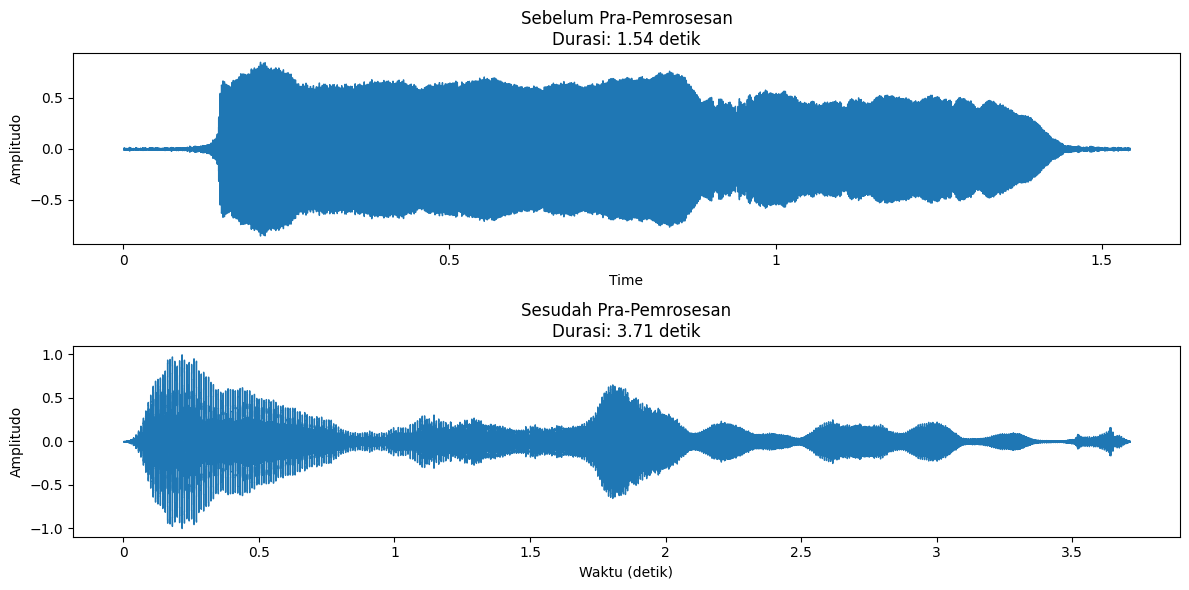

In [10]:
# ============================================================
# VISUALISASI SEBELUM DAN SESUDAH PRA-PEMROSESAN
# ============================================================

from pathlib import Path
import random
import librosa
import librosa.display
import matplotlib.pyplot as plt

def plot_before_after_preprocessing(original_file, processed_file, save_path=None):
    y1,sr1=librosa.load(original_file,sr=None,mono=True)
    y2,sr2=librosa.load(processed_file,sr=None,mono=True)

    d1=librosa.get_duration(y=y1,sr=sr1)
    d2=librosa.get_duration(y=y2,sr=sr2)

    fig,ax=plt.subplots(2,1,figsize=(12,6))

    librosa.display.waveshow(y1,sr=sr1,ax=ax[0])
    ax[0].set_title(f"Sebelum Pra-Pemrosesan\nDurasi: {d1:.2f} detik")
    ax[0].set_ylabel("Amplitudo")

    librosa.display.waveshow(y2,sr=sr2,ax=ax[1])
    ax[1].set_title(f"Sesudah Pra-Pemrosesan\nDurasi: {d2:.2f} detik")
    ax[1].set_xlabel("Waktu (detik)")
    ax[1].set_ylabel("Amplitudo")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path,dpi=300,bbox_inches="tight")
        print(f"Gambar tersimpan: {save_path}")

    plt.show()


# ===============================
# RANDOM AUDIO (ORANG SAMA)
# ===============================

PROJECT_DIR=CONFIG["drive_project_dir"]
random.seed(42)

LABEL=random.choice(CONFIG["classes"])

RAW_ROOT=PROJECT_DIR/"Dataset"/"Raw"/"Internal"/LABEL
PROCESSED_ROOT=PROJECT_DIR/"Dataset"/"Processed"


# pilih penyanyi
singers=[x for x in RAW_ROOT.iterdir() if x.is_dir()]

if not singers:
    raise FileNotFoundError("Folder penyanyi tidak ditemukan")

SINGER=random.choice(singers)


# pilih rekaman
raw_files=[]

for ext in CONFIG["supported_extensions"]:
    raw_files+=list(SINGER.glob(f"*{ext}"))

if not raw_files:
    raise FileNotFoundError("File audio tidak ditemukan")

RAW_FILE=random.choice(raw_files)


# cari processed nama sama
stem=RAW_FILE.stem

processed_files=[]

for ext in CONFIG["supported_extensions"]:
    processed_files+=list(PROCESSED_ROOT.rglob(f"{stem}*{ext}"))

if not processed_files:
    raise FileNotFoundError(f"Processed tidak ditemukan untuk {stem}")

PROCESSED_FILE=processed_files[0]


print("Kelas :",LABEL)
print("Penyanyi :",SINGER.name)
print("File :",RAW_FILE.name)
print("\nBefore:",RAW_FILE)
print("After :",PROCESSED_FILE)


plot_before_after_preprocessing(
    RAW_FILE,
    PROCESSED_FILE,
    PROJECT_DIR/"Gambar_4_2_Preprocessing.png"
)

# 8. Metadata Generation

Bagian ini membuat `metadata_audio.csv` dari seluruh audio yang berhasil diproses. Metadata memuat tipe dataset, kelas, penyanyi, variasi, path file, durasi, sample rate, jumlah sampel, dan jumlah frame. Bagian ini juga membuat visualisasi distribusi dataset dan distribusi penyanyi.


In [11]:
#CHECK READ HASIL PROCESSING

print(PATHS["working_processed"])

for p in Path(PATHS["working_processed"]).rglob("*.wav"):
    print(p)
    break

/content/satb_working/ProcessedAll
/content/satb_working/ProcessedAll/Secondary/Soprano/S03/R2_3.wav


In [12]:
# ============================================================
# CHECK VARIATION HASIL PROCESSING
# ============================================================

test_file = Path("/content/satb_working/ProcessedAll/Internal/Soprano/S01 - nata/R1_1.wav")

print(detect_variation(
    test_file,
    {
        v: re.compile(rf"(^|[_\-\s]){re.escape(v.upper())}($|[_\-\s])")
        for v in CONFIG["internal_variations"]
    }
))

R1


#8-1 Metadata Generation dan Visualisasi Metadata

In [13]:
# ============================================================
# METADATA GENERATION FROM PROCESSED AUDIO (OPTIMIZED + SEKUNDER)
# ============================================================

from pathlib import Path
from typing import Dict, Any, List
import logging
import re
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

def read_processed_audio_metadata(args: tuple) -> Dict[str, Any]:
    """Read metadata from processed audio file (Thread-safe wrapper)."""
    audio_path, dataset_type, class_name, singer_id, variation = args

    row = {
        "dataset_type": dataset_type,
        "class_name": class_name,
        "singer_id": singer_id,
        "variation": variation,
        "file_name": audio_path.name,
        "file_path": str(audio_path),
        "sample_rate": np.nan,
        "duration_seconds": np.nan,
        "n_samples": np.nan,
        "n_frames": np.nan,
        "status": "ok",
        "error_message": ""
    }
    try:
        info = sf.info(audio_path)
        row["sample_rate"] = int(info.samplerate)
        row["duration_seconds"] = float(info.duration)
        row["n_samples"] = int(info.frames)
        row["n_frames"] = int(1 + max(0, info.frames - CONFIG["n_fft"]) // CONFIG["hop_length"])
    except Exception as exc:
        row["status"] = "failed"
        row["error_message"] = str(exc)
        logging.error("Failed reading %s : %s", audio_path, exc)
    return row


def generate_audio_metadata() -> pd.DataFrame:
    # Build pattern dictionaries dynamically
    patterns_map = {
        "Internal": {v: re.compile(rf"(^|[_\-\s]){re.escape(v.upper())}($|[_\-\s])") for v in CONFIG.get("internal_variations", [])},
        "External": {v: re.compile(rf"(^|[_\-\s]){re.escape(v.upper())}($|[_\-\s])") for v in CONFIG.get("external_variations", [])},
        "Sekunder": {v: re.compile(rf"(^|[_\-\s]){re.escape(v.upper())}($|[_\-\s])") for v in CONFIG.get("secondary_variations", CONFIG.get("internal_variations", []))}
    }

    # ========================================================
    # Detect processed dataset automatically
    # ========================================================
    candidates = [
        PATHS.get("working_processed"),
        PATHS.get("final_dataset"),
        PATHS.get("segmented"),
    ]

    base = None
    for folder in candidates:
        if folder is None:
            continue
        folder = Path(folder)
        if folder.exists() and any(folder.rglob("*.wav")):
            base = folder
            break

    if base is None:
        raise FileNotFoundError(
            "Tidak ditemukan dataset hasil preprocessing. "
            "Pastikan preprocessing telah selesai."
        )

    print("="*60)
    print("SOURCE DATASET")
    print("="*60)
    print(base)

    # Detect available dataset subfolders dynamically (Internal, External, Sekunder, etc.)
    dataset_types = [d.name for d in base.iterdir() if d.is_dir()]

    # Collect scanning tasks
    tasks = []
    for dataset_type in dataset_types:
        dataset_dir = base / dataset_type
        patterns = patterns_map.get(dataset_type, patterns_map["Internal"])

        for class_name in CONFIG["classes"]:
            class_dir = dataset_dir / class_name
            if not class_dir.exists():
                continue

            singer_dirs = [p for p in class_dir.iterdir() if p.is_dir()]
            for singer_dir in singer_dirs:
                wav_files = sorted(singer_dir.glob("*.wav"))
                for audio_path in wav_files:
                    variation = detect_variation(audio_path, patterns)
                    tasks.append((audio_path, dataset_type, class_name, singer_dir.name, variation))

    print(f"Scanning metadata for {len(tasks)} audio files...")

    # Fast parallel execution using ThreadPoolExecutor (I/O bound task)
    records = []
    max_workers = min(32, (os.cpu_count() or 4) * 4)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(tqdm(executor.map(read_processed_audio_metadata, tasks), total=len(tasks), desc="Reading audio info"))
        records.extend(results)

    return pd.DataFrame(records)


# ============================================================
# RUN METADATA GENERATION
# ============================================================

audio_metadata_df = generate_audio_metadata()

if audio_metadata_df.empty:
    raise RuntimeError(
        "Metadata kosong. Tidak ditemukan file WAV pada dataset hasil preprocessing."
    )

PATHS["metadata"].mkdir(parents=True, exist_ok=True)
PATHS["result"].mkdir(parents=True, exist_ok=True)

metadata_audio_path = PATHS["metadata"] / "metadata_audio.csv"
audio_metadata_df.to_csv(metadata_audio_path, index=False)

print("\n" + "="*60)
print("METADATA GENERATION RESULT")
print("="*60)
print("Total files :", len(audio_metadata_df))
print("Saved       :", metadata_audio_path)


# ============================================================
# DATASET SUMMARY (DYNAMIC FOR ALL TYPES INCLUDING SEKUNDER)
# ============================================================

print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)

summary_stats = (
    audio_metadata_df.groupby(["class_name", "dataset_type"])
    .agg(record_count=("file_name", "count"), singer_count=("singer_id", "nunique"))
    .reset_index()
)

for class_name in CONFIG["classes"]:
    class_data = summary_stats[summary_stats["class_name"] == class_name]
    summary_str_list = []

    for _, row in class_data.iterrows():
        summary_str_list.append(
            f"{row['dataset_type']}: {row['record_count']:>3} rec ({row['singer_count']:>2} singer)"
        )

    summary_str = " | ".join(summary_str_list) if summary_str_list else "No data"
    print(f"{class_name:<8} | {summary_str}")

print("-" * 60)
print("Total Recordings :", len(audio_metadata_df))
print("Total Singers    :", audio_metadata_df["singer_id"].nunique())


# ============================================================
# DURATION SUMMARY
# ============================================================

print("\n" + "="*60)
print("DURATION SUMMARY")
print("="*60)

print(f"Average : {audio_metadata_df.duration_seconds.mean():.2f} sec")
print(f"Minimum : {audio_metadata_df.duration_seconds.min():.2f} sec")
print(f"Maximum : {audio_metadata_df.duration_seconds.max():.2f} sec")


# ============================================================
# FRAME SUMMARY
# ============================================================

print("\n" + "="*60)
print("FRAME SUMMARY")
print("="*60)

print(f"Average : {audio_metadata_df.n_frames.mean():.0f}")
print(f"Minimum : {audio_metadata_df.n_frames.min():.0f}")
print(f"Maximum : {audio_metadata_df.n_frames.max():.0f}")

SOURCE DATASET
/content/satb_working/ProcessedAll
Scanning metadata for 1850 audio files...


Reading audio info:   0%|          | 0/1850 [00:00<?, ?it/s]


METADATA GENERATION RESULT
Total files : 1850
Saved       : /content/drive/MyDrive/SATB_Model/Dataset/Metadata/metadata_audio.csv

DATASET SUMMARY
Soprano  | External:  70 rec ( 5 singer) | Internal: 351 rec (16 singer) | Secondary:  48 rec ( 4 singer)
Alto     | External:  58 rec ( 4 singer) | Internal: 345 rec (16 singer) | Secondary:  48 rec ( 4 singer)
Tenor    | External:  73 rec ( 5 singer) | Internal: 326 rec (16 singer) | Secondary:  48 rec ( 4 singer)
Bass     | External:  68 rec ( 5 singer) | Internal: 367 rec (15 singer) | Secondary:  48 rec ( 4 singer)
------------------------------------------------------------
Total Recordings : 1850
Total Singers    : 82

DURATION SUMMARY
Average : 4.87 sec
Minimum : 0.22 sec
Maximum : 40.94 sec

FRAME SUMMARY
Average : 149
Minimum : 4
Maximum : 1276


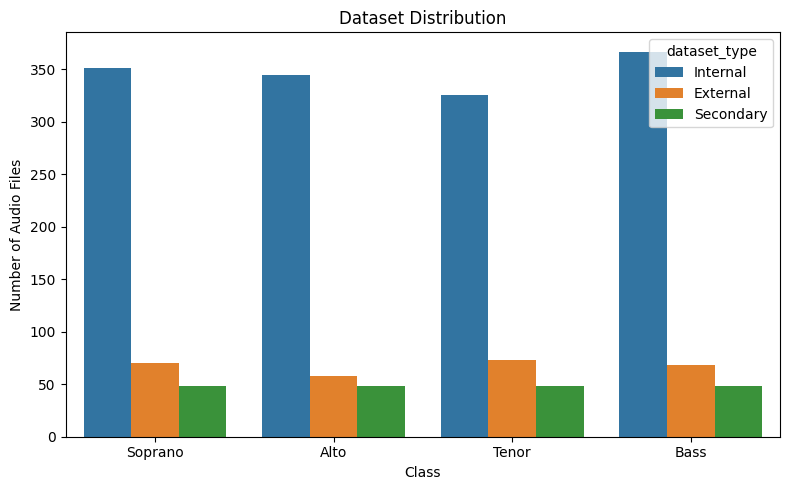

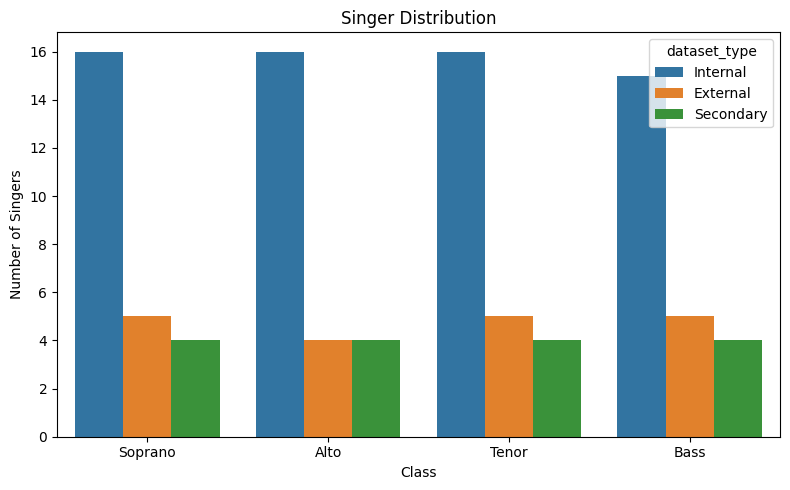

AUDIO METADATA PREVIEW


,dataset_type,class_name,singer_id,variation,file_name,sample_rate,duration_seconds,n_samples,n_frames,status
0,Internal,Soprano,S15 - Febri,R1,R1_1.wav,16000,3.118,49888,94,ok
1,Internal,Soprano,S15 - Febri,R1,R1_2.wav,16000,3.452,55232,104,ok
2,Internal,Soprano,S15 - Febri,R1,R1_3.wav,16000,3.104,49664,94,ok
3,Internal,Soprano,S15 - Febri,R1,R1_4.wav,16000,3.328,53248,101,ok
4,Internal,Soprano,S15 - Febri,R1,R1_5.wav,16000,3.104,49664,94,ok
5,Internal,Soprano,S15 - Febri,R1,R1_6.wav,16000,3.264,52224,99,ok
6,Internal,Soprano,S15 - Febri,R1,R1_7.wav,16000,3.040,48640,92,ok
7,Internal,Soprano,S15 - Febri,R1,R1_8.wav,16000,3.456,55296,105,ok
8,Internal,Soprano,S15 - Febri,R2,R2_1.wav,16000,3.420,54720,103,ok
9,Internal,Soprano,S15 - Febri,R2,R2_2.wav,16000,3.360,53760,102,ok


RECORDING DISTRIBUTION


,dataset_type,class_name,recording_count
0,External,Alto,58
1,External,Bass,68
2,External,Soprano,70
3,External,Tenor,73
4,Internal,Alto,345
5,Internal,Bass,367
6,Internal,Soprano,351
7,Internal,Tenor,326
8,Secondary,Alto,48
9,Secondary,Bass,48


In [14]:
# ============================================================
# METADATA VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

PATHS["result"].mkdir(parents=True,exist_ok=True)

# DATASET DISTRIBUTION
plt.figure(figsize=(8,5))
sns.countplot(
    data=audio_metadata_df,
    x="class_name",
    hue="dataset_type",
    order=CONFIG["classes"]
)
plt.title("Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Audio Files")
plt.tight_layout()
plt.savefig(PATHS["result"]/ "dataset_distribution.png",dpi=160,bbox_inches="tight")
plt.show()
plt.close()


# SINGER DISTRIBUTION
singer_distribution=audio_metadata_df.drop_duplicates(
    ["dataset_type","class_name","singer_id"]
)

plt.figure(figsize=(8,5))
sns.countplot(
    data=singer_distribution,
    x="class_name",
    hue="dataset_type",
    order=CONFIG["classes"]
)
plt.title("Singer Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Singers")
plt.tight_layout()
plt.savefig(PATHS["result"]/ "singer_distribution.png",dpi=160,bbox_inches="tight")
plt.show()
plt.close()


# CLEAN TABLE DISPLAY
print("="*60)
print("AUDIO METADATA PREVIEW")
print("="*60)

display(
    audio_metadata_df[
        [
            "dataset_type",
            "class_name",
            "singer_id",
            "variation",
            "file_name",
            "sample_rate",
            "duration_seconds",
            "n_samples",
            "n_frames",
            "status"
        ]
    ].head(20)
)


print("="*60)
print("RECORDING DISTRIBUTION")
print("="*60)

display(
    audio_metadata_df
    .groupby(["dataset_type","class_name"])
    .size()
    .reset_index(name="recording_count")
    .sort_values(["dataset_type","class_name"])
)

# 9. Dataset Split

Bagian ini membagi dataset internal berdasarkan penyanyi, bukan berdasarkan rekaman. Dengan demikian semua variasi dari penyanyi yang sama hanya muncul pada satu subset, sehingga data leakage dapat dicegah. Rasio split adalah 70% train, 15% validation, dan 15% test dengan random seed 42. Dataset eksternal tidak dimasukkan ke split internal.


2026-09-15 12:47:06,508 | INFO | Split metadata saved: /content/drive/MyDrive/SATB_Model/Dataset/Metadata/metadata_split.csv
2026-09-15 12:47:06,509 | INFO | Dataset metadata saved: /content/drive/MyDrive/SATB_Model/Dataset/Metadata/metadata_dataset.csv


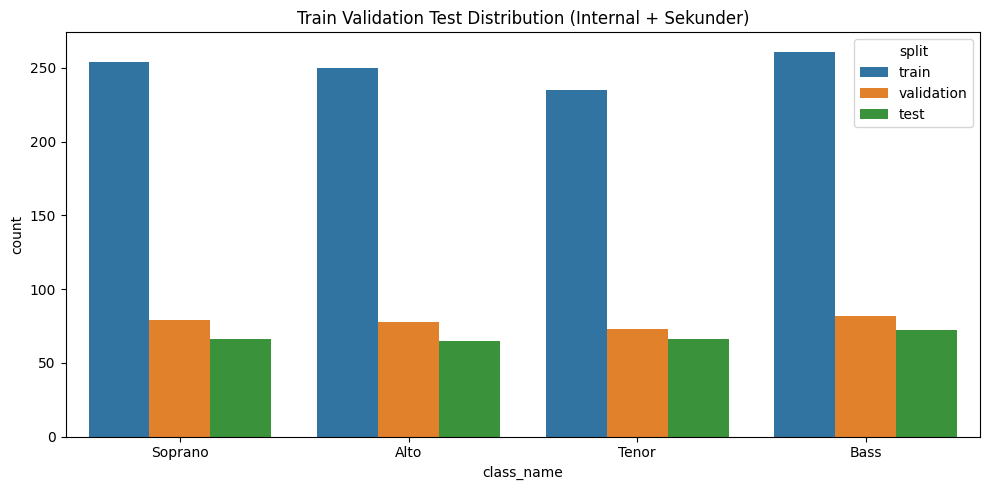


RECORDING COUNT PER SPLIT & CLASS & DATASET TYPE


,split,class_name,dataset_type,recording_count
0,test,Alto,Internal,65
1,test,Bass,Internal,72
2,test,Soprano,Internal,66
3,test,Tenor,Internal,66
4,train,Alto,Internal,214
5,train,Alto,Secondary,36
6,train,Bass,Internal,225
7,train,Bass,Secondary,36
8,train,Soprano,Internal,218
9,train,Soprano,Secondary,36



SINGER COUNT PER SPLIT & CLASS & DATASET TYPE


,split,class_name,dataset_type,singer_count
0,test,Alto,Internal,3
1,test,Bass,Internal,3
2,test,Soprano,Internal,3
3,test,Tenor,Internal,3
4,train,Alto,Internal,10
5,train,Alto,Secondary,3
6,train,Bass,Internal,9
7,train,Bass,Secondary,3
8,train,Soprano,Internal,10
9,train,Soprano,Secondary,3


In [31]:
# ============================================================
# 9. DATASET SPLIT (TEST HANYA INTERNAL, TRAIN & VAL = INTERNAL + SEKUNDER)
# ============================================================

import random
import numpy as np
import pandas as pd
from pathlib import Path
import shutil
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple

# Pemetaan Manual untuk Data Internal
MANUAL_SPLIT = {
    "Soprano": {
        "validation": [
            "S04 - kezia",
            "S06 - Dewingga",
            "S11 - Mersya"
        ],
        "test": [
            "S08 - gracel",
            "S12 - tasa",
            "S13 - tin"
        ]
    },
    "Alto": {
        "validation": [
            "A04 - Uut",
            "A10 - joy",
            "A11 - yaya"
        ],
        "test": [
            "A16 - teman teguh",
            "A06 - omk",
            "A12 - iffah"
        ]
    },
    "Tenor": {
        "validation": [
            "T05 - esau",
            "T09 - omk",
            "T15 - Agung"
        ],
        "test": [
            "T16 - Atus omk",
            "T07 - julian",
            "T11 - fais"
        ]
    },
    "Bass": {
        "validation": [
            "B09 - Ofel",
            "B07 - randi",
            "B10 - Tio"
        ],
        "test": [
            "B14 - Reyy",
            "B15 - Okky",
            "B16 - Emha"
        ]
    }
}


def create_singer_level_split(audio_metadata: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    """
    Split dataset secara Speaker-Independent:
    - Internal           : Train, Validation, & Test (berdasarkan MANUAL_SPLIT).
    - Sekunder/Secondary : Hanya Train & Validation (Test = 0).
    """
    split_map = {}

    df = audio_metadata.copy()
    df["dataset_type_clean"] = df["dataset_type"].astype(str).str.strip().str.capitalize()

    # ------------------------------------------------------------
    # 1. PROCESS INTERNAL DATA (MANUAL SPLIT: TRAIN, VAL, TEST)
    # ------------------------------------------------------------
    internal_df = df[df["dataset_type_clean"] == "Internal"].copy()
    if internal_df.empty:
        raise ValueError("Data Internal tidak ditemukan dalam audio_metadata.")

    for cls in CONFIG["classes"]:
        singers = set(internal_df.loc[internal_df["class_name"] == cls, "singer_id"].dropna().unique())
        val = set(MANUAL_SPLIT[cls]["validation"])
        test = set(MANUAL_SPLIT[cls]["test"])

        if val & test:
            raise ValueError(f"{cls} Internal: Validation dan Test mengandung singer yang sama: {val & test}")

        unknown = (val | test) - singers
        if unknown:
            raise ValueError(f"{cls} Internal: Singer tidak dikenal di MANUAL_SPLIT: {unknown}")

        for s in singers:
            split_map[(cls, s)] = "train"
        for s in val:
            split_map[(cls, s)] = "validation"
        for s in test:
            split_map[(cls, s)] = "test"

    # ------------------------------------------------------------
    # 2. PROCESS SEKUNDER / SECONDARY DATA (TRAIN & VAL ONLY)
    # ------------------------------------------------------------
    sekunder_mask = df["dataset_type_clean"].isin(["Sekunder", "Secondary"])
    sekunder_df = df[sekunder_mask].copy()
    rng = np.random.default_rng(seed)

    if not sekunder_df.empty:
        for cls in CONFIG["classes"]:
            cls_singers = sorted(list(sekunder_df.loc[sekunder_df["class_name"] == cls, "singer_id"].dropna().unique()))
            if not cls_singers:
                continue

            # Acak urutan penyanyi
            rng.shuffle(cls_singers)
            n_total = len(cls_singers)

            # Misal 4 penyanyi Sekunder: 3 ke Train, 1 ke Validation (0 ke Test)
            n_val = max(1, int(round(n_total * 0.25))) if n_total >= 3 else 0
            n_train = n_total - n_val

            train_singers = cls_singers[:n_train]
            val_singers = cls_singers[n_train:]

            for s in train_singers:
                split_map[(cls, s)] = "train"
            for s in val_singers:
                split_map[(cls, s)] = "validation"

    # ------------------------------------------------------------
    # 3. MERGE SPLIT TO DATAFRAME & VALIDATE LEAKAGE
    # ------------------------------------------------------------
    target_mask = df["dataset_type_clean"].isin(["Internal", "Sekunder", "Secondary"])
    target_df = df[target_mask].copy()

    target_df["split"] = target_df.set_index(["class_name", "singer_id"]).index.map(pd.Series(split_map))

    # Validasi Data Leakage
    leakage = target_df.groupby("singer_id")["split"].nunique()
    if (leakage > 1).any():
        leaked_singers = leakage[leakage > 1].index.tolist()
        raise ValueError(f"Data leakage terdeteksi untuk singer: {leaked_singers}")

    return target_df.drop(columns=["dataset_type_clean"], errors="ignore")


def materialize_processed_split(split_df: pd.DataFrame, audio_metadata: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Salin file audio ke folder tujuan sesuai split masing-masing."""
    split_to_path = {
        "train": "processed_train",
        "validation": "processed_validation",
        "test": "processed_test"
    }
    main_rows, external_rows = [], []

    # Salin Train, Validation, & Test
    for row in split_df.itertuples(index=False):
        dst = PATHS[split_to_path[row.split]] / row.class_name / row.singer_id / Path(row.file_path).name
        dst.parent.mkdir(parents=True, exist_ok=True)
        if not dst.exists():
            shutil.copy(row.file_path, dst)

        data = row._asdict()
        data["source_working_path"] = data["file_path"]
        data["file_path"] = str(dst)
        main_rows.append(data)

    # Salin External Data
    ext_mask = audio_metadata["dataset_type"].astype(str).str.strip().str.capitalize() == "External"
    external_df = audio_metadata[ext_mask].copy()

    for row in external_df.itertuples(index=False):
        dst = PATHS["processed_external"] / row.class_name / row.singer_id / Path(row.file_path).name
        dst.parent.mkdir(parents=True, exist_ok=True)
        if not dst.exists():
            shutil.copy(row.file_path, dst)

        data = row._asdict()
        data["split"] = "external"
        data["source_working_path"] = data["file_path"]
        data["file_path"] = str(dst)
        external_rows.append(data)

    return pd.DataFrame(main_rows), pd.DataFrame(external_rows)


# ============================================================
# RUN DATASET SPLIT STAGE
# ============================================================

try:
    split_df = create_singer_level_split(audio_metadata_df, seed=42)
    split_df, external_processed_df = materialize_processed_split(split_df, audio_metadata_df)

    split_path = PATHS["metadata"] / "metadata_split.csv"
    dataset_metadata_path = PATHS["metadata"] / "metadata_dataset.csv"

    split_df.to_csv(split_path, index=False)
    pd.concat([split_df, external_processed_df], ignore_index=True).to_csv(dataset_metadata_path, index=False)

    logging.info("Split metadata saved: %s", split_path)
    logging.info("Dataset metadata saved: %s", dataset_metadata_path)

    # Visualisasi
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=split_df,
        x="class_name",
        hue="split",
        order=CONFIG["classes"],
        hue_order=["train", "validation", "test"]
    )
    plt.title("Train Validation Test Distribution (Internal + Sekunder)")
    plt.tight_layout()
    plt.savefig(PATHS["result"] / "train_validation_test_distribution.png", dpi=160)
    plt.show()

    print("\n" + "="*60)
    print("RECORDING COUNT PER SPLIT & CLASS & DATASET TYPE")
    print("="*60)
    display(
        split_df.groupby(["split", "class_name", "dataset_type"])
        .size()
        .reset_index(name="recording_count")
    )

    print("\n" + "="*60)
    print("SINGER COUNT PER SPLIT & CLASS & DATASET TYPE")
    print("="*60)
    display(
        split_df.drop_duplicates(["class_name", "singer_id", "split"])
        .groupby(["split", "class_name", "dataset_type"])
        .size()
        .reset_index(name="singer_count")
    )

except Exception as e:
    logging.exception("Dataset split stage failed.")
    raise RuntimeError(f"Dataset split failed: {e}") from e

# 10. Data Augmentation

Bagian ini menerapkan augmentasi hanya pada subset training. Validation dan test tidak pernah diaugmentasi. Untuk setiap rekaman training dibuat empat versi: pitch shift, time stretch, Gaussian noise, dan gain. Hasil disimpan di `Dataset/Augmented/Train/`.


In [ ]:
!pip install -q pedalboard

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 91.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# DATA AUGMENTATION (HIGH-SPEED & SAFE PIPELINE)
# ============================================================

import json
import logging
import zlib
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path
from typing import Any, Dict, List

import librosa
import numpy as np
import pandas as pd
import soundfile as sf
from tqdm.auto import tqdm

# Cek apakah pedalboard terinstall untuk Pitch Shift super cepat
try:
    from pedalboard import Pedalboard, PitchShift
    HAS_PEDALBOARD = True
except ImportError:
    HAS_PEDALBOARD = False
    logging.warning("Pedalboard tidak terinstall. Menggunakan fallback librosa (lebih lambat).")


def save_augmented_audio(audio: np.ndarray, output_path: Path) -> None:
    """Menyimpan audio ter-augmentasi dengan peak normalization agar tidak clipping."""
    peak = np.max(np.abs(audio))
    if peak > 0:
        audio = audio / peak
    output_path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(output_path, audio, CONFIG["sample_rate"], subtype=CONFIG["pcm_subtype"])


def fast_pitch_shift(audio: np.ndarray, sample_rate: int, semitone: float) -> np.ndarray:
    """Pitch shift berkecepatan tinggi menggunakan C++ backend (Pedalboard)."""
    if HAS_PEDALBOARD:
        board = Pedalboard([PitchShift(semitones=semitone)])
        return board(audio, sample_rate)
    return librosa.effects.pitch_shift(audio, sr=sample_rate, n_steps=semitone)


def augment_worker_process(record_dict: Dict[str, Any]) -> List[Dict[str, Any]]:
    """
    Worker function top-level untuk ProcessPoolExecutor.
    Menerapkan augmentasi aman dengan performa komputasi tinggi.
    """
    source_path = Path(record_dict["file_path"])
    class_name = record_dict["class_name"]
    singer_id = record_dict["singer_id"]
    variation = record_dict.get("variation", "")
    dataset_type = record_dict.get("dataset_type", "Internal")

    sample_rate = CONFIG["sample_rate"]
    trim_top_db = CONFIG["trim_top_db"]
    output_dir = PATHS["augmented_train"] / class_name / singer_id
    source_name = source_path.stem

    # Seed unik berbasis file path menggunakan adler32 (Konsisten & reproducible)
    path_hash = zlib.adler32(str(source_path).encode("utf-8"))
    rng = np.random.default_rng(CONFIG["random_seed"] + (path_hash % 1_000_000))

    records = []

    try:
        # ------------------------------------------------------------
        # 1. LOAD & TRIMMING (Mengeksekusi audio ter-clean dari processed_train)
        # ------------------------------------------------------------
        audio, sr = load_audio_mono(source_path, sample_rate)
        audio = trim_silence(audio, trim_top_db)
        audio = peak_normalize(audio)

        # ------------------------------------------------------------
        # 2. PARAMETER AUGMENTASI AMAN (MENJAGA REGISTER PITCH SATB)
        # ------------------------------------------------------------
        # A. Pitch Shift Sangat Tipis (Maksimal ±0.5 semitone)
        semitone = float(rng.uniform(-0.5, 0.5))
        if abs(semitone) < 0.1:
            semitone = 0.3 * (1.0 if semitone >= 0 else -1.0)

        # B. Time Shift Ringan (Maksimal 10% durasi)
        max_shift_samples = int(len(audio) * 0.10)
        shift_amount = int(rng.integers(-max_shift_samples, max_shift_samples))

        # C. Gain / Volume Adjustment (±2 hingga ±3 dB)
        gain_db = float(rng.uniform(-3.0, 3.0))

        # D. Add White Noise Berbasis SNR Halus (25 dB - 35 dB)
        snr_db = float(rng.uniform(25.0, 35.0))
        signal_power = np.mean(audio ** 2)
        noise_power = signal_power / (10 ** (snr_db / 10.0))
        white_noise = rng.normal(0, np.sqrt(noise_power), audio.shape).astype(np.float32)

        # ------------------------------------------------------------
        # 3. DAFTAR AUGMENTASI AMAN
        # ------------------------------------------------------------
        available_augmentations = [
            ("pitch_shift_light",
             lambda: fast_pitch_shift(audio, sample_rate, semitone),
             {"semitones": semitone}),

            ("time_shift",
             lambda: np.roll(audio, shift_amount),
             {"shift_samples": shift_amount}),

            ("gain_db",
             lambda: audio * (10.0 ** (gain_db / 20.0)),
             {"gain_db": gain_db}),

            ("snr_white_noise",
             lambda: audio + white_noise,
             {"snr_db": snr_db}),
        ]

        # ------------------------------------------------------------
        # 4. RANDOM PICK (1 Teknik per sampel)
        # ------------------------------------------------------------
        selected_idx = rng.choice(len(available_augmentations))
        aug_name, aug_func, params = available_augmentations[selected_idx]

        # Eksekusi fungsi augmentasi
        aug_audio = aug_func()
        aug_audio = peak_normalize(aug_audio)

        # Simpan audio ter-augmentasi
        output_path = output_dir / f"{source_name}_aug_{aug_name}.wav"
        save_augmented_audio(aug_audio, output_path)

        records.append({
            "class_name": class_name,
            "singer_id": singer_id,
            "variation": variation,
            "dataset_type": dataset_type,
            "source_file": source_path.name,
            "source_path": str(source_path),
            "output_path": str(output_path),
            "augmentation": aug_name,
            "parameters": json.dumps(params),
            "status": "ok",
            "error_message": "",
        })

    except Exception as exc:
        logging.error("Failed augmenting %s: %s", source_path, exc)
        records.append({
            "class_name": class_name,
            "singer_id": singer_id,
            "variation": variation,
            "dataset_type": dataset_type,
            "source_file": source_path.name,
            "source_path": str(source_path),
            "output_path": "",
            "augmentation": "",
            "parameters": "{}",
            "status": "failed",
            "error_message": str(exc),
        })

    return records


# ============================================================
# RUNNING PROCESS (FAST MULTI-PROCESS PIPELINE)
# ============================================================
try:
    # Mengambil hanya data 'train' (Internal + Secondary)
    train_df = split_df.loc[split_df["split"] == "train"].copy()
    train_records = train_df.to_dict(orient="records")

    augmentation_rows = []

    # Menggunakan ProcessPoolExecutor untuk paralelisasi CPU multi-core
    with ProcessPoolExecutor() as executor:
        futures = [executor.submit(augment_worker_process, rec) for rec in train_records]

        for future in tqdm(
            as_completed(futures),
            total=len(train_records),
            desc="Augmenting Training Data (High-Speed Multi-Core)"
        ):
            augmentation_rows.extend(future.result())

    augmentation_df = pd.DataFrame(augmentation_rows)

    augmentation_path = PATHS["metadata"] / "metadata_augmentation.csv"
    augmentation_df.to_csv(augmentation_path, index=False)

    logging.info("Augmentation metadata saved: %s", augmentation_path)

    print("\n" + "="*60)
    print("RINGKASAN HASIL AUGMENTASI PER DATASET TYPE & TEKNIK")
    print("="*60)
    display(
        augmentation_df.groupby(["dataset_type", "status", "augmentation"], dropna=False)
        .size()
        .reset_index(name="count")
    )

    print("\n" + "="*60)
    print("RINGKASAN AUGMENTASI PER KELAS SATB")
    print("="*60)
    display(
        augmentation_df.groupby(["dataset_type", "class_name", "status"])
        .size()
        .reset_index(name="count")
    )

    print("\n Preview Metadata Augmentasi:")
    display(augmentation_df.head(10))

except Exception as stage_exc:
    logging.exception("Data augmentation stage failed.")
    raise RuntimeError(f"Data augmentation failed: {stage_exc}") from stage_exc

Augmenting Training Data (High-Speed Multi-Core):   0%|          | 0/1000 [00:00<?, ?it/s]

2026-08-07 12:20:50,470 | INFO | Augmentation metadata saved: /content/drive/MyDrive/SATB_Model/Dataset/Metadata/metadata_augmentation.csv

RINGKASAN HASIL AUGMENTASI PER DATASET TYPE & TEKNIK


,dataset_type,status,augmentation,count
0,Internal,ok,gain_db,215
1,Internal,ok,pitch_shift_light,233
2,Internal,ok,snr_white_noise,215
3,Internal,ok,time_shift,193
4,Secondary,ok,gain_db,41
5,Secondary,ok,pitch_shift_light,36
6,Secondary,ok,snr_white_noise,33
7,Secondary,ok,time_shift,34



RINGKASAN AUGMENTASI PER KELAS SATB


,dataset_type,class_name,status,count
0,Internal,Alto,ok,214
1,Internal,Bass,ok,225
2,Internal,Soprano,ok,218
3,Internal,Tenor,ok,199
4,Secondary,Alto,ok,36
5,Secondary,Bass,ok,36
6,Secondary,Soprano,ok,36
7,Secondary,Tenor,ok,36



 Preview Metadata Augmentasi:


,class_name,singer_id,variation,dataset_type,source_file,source_path,output_path,augmentation,parameters,status,error_message
0,Soprano,S04,R1,Secondary,R1_1.wav,/content/drive/MyDrive/SATB_Model/Dataset/Proc...,/content/drive/MyDrive/SATB_Model/Dataset/Augm...,time_shift,"{""shift_samples"": 1954}",ok,
1,Soprano,S04,R1,Secondary,R1_2.wav,/content/drive/MyDrive/SATB_Model/Dataset/Proc...,/content/drive/MyDrive/SATB_Model/Dataset/Augm...,gain_db,"{""gain_db"": -0.8895862143048827}",ok,
2,Soprano,S04,R1,Secondary,R1_4.wav,/content/drive/MyDrive/SATB_Model/Dataset/Proc...,/content/drive/MyDrive/SATB_Model/Dataset/Augm...,gain_db,"{""gain_db"": 1.2998295242911082}",ok,
3,Soprano,S04,R1,Secondary,R1_3.wav,/content/drive/MyDrive/SATB_Model/Dataset/Proc...,/content/drive/MyDrive/SATB_Model/Dataset/Augm...,pitch_shift_light,"{""semitones"": 0.38709207399991485}",ok,
4,Soprano,S04,R2,Secondary,R2_2.wav,/content/drive/MyDrive/SATB_Model/Dataset/Proc...,/content/drive/MyDrive/SATB_Model/Dataset/Augm...,gain_db,"{""gain_db"": 1.232243295555505}",ok,
5,Soprano,S04,R2,Secondary,R2_1.wav,/content/drive/MyDrive/SATB_Model/Dataset/Proc...,/content/drive/MyDrive/SATB_Model/Dataset/Augm...,pitch_shift_light,"{""semitones"": 0.3}",ok,
6,Soprano,S04,R2,Secondary,R2_3.wav,/content/drive/MyDrive/SATB_Model/Dataset/Proc...,/content/drive/MyDrive/SATB_Model/Dataset/Augm...,gain_db,"{""gain_db"": -1.7064147180502365}",ok,
7,Soprano,S04,R2,Secondary,R2_4.wav,/content/drive/MyDrive/SATB_Model/Dataset/Proc...,/content/drive/MyDrive/SATB_Model/Dataset/Augm...,pitch_shift_light,"{""semitones"": -0.189404313938642}",ok,
8,Soprano,S04,R3,Secondary,R3_1.wav,/content/drive/MyDrive/SATB_Model/Dataset/Proc...,/content/drive/MyDrive/SATB_Model/Dataset/Augm...,pitch_shift_light,"{""semitones"": -0.13465087248961738}",ok,
9,Soprano,S04,R3,Secondary,R3_2.wav,/content/drive/MyDrive/SATB_Model/Dataset/Proc...,/content/drive/MyDrive/SATB_Model/Dataset/Augm...,snr_white_noise,"{""snr_db"": 31.418306209893437}",ok,


# 11. MFCC Extraction

Bagian ini mengekstraksi MFCC menggunakan `librosa` dengan 40 koefisien, FFT 2048, hop length 512, dan window Hann. Agar kompatibel dengan CNN, semua matriks MFCC dipadatkan ke jumlah frame tetap. Ukuran frame tetap dihitung dari data internal dan augmentasi training, bukan dari dataset eksternal, agar external test tetap murni sebagai evaluasi luar.


In [34]:
# ============================================================
# HYBRID FEATURE EXTRACTION + SPECAUGMENT
# MFCC + DELTA + DELTA-DELTA + CHROMA
# TANPA AUDIO AUGMENTATION
# ============================================================

import logging
from pathlib import Path
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm import tqdm

# ------------------------------------------------------------
# LABEL
# ------------------------------------------------------------
LABEL_TO_INDEX = {
    label: i for i, label in enumerate(CONFIG["classes"])
}
INDEX_TO_LABEL = {
    i: label for label, i in LABEL_TO_INDEX.items()
}

# ------------------------------------------------------------
# REPRODUCIBLE RANDOM GENERATOR
# ------------------------------------------------------------
RNG = np.random.default_rng(CONFIG["random_seed"])

# ------------------------------------------------------------
# SPECAUGMENT
# ------------------------------------------------------------
def apply_spec_augment(
    features,
    freq_mask_max=3,
    time_mask_max=25,
    n_freq_masks=1,
    n_time_masks=1
):
    aug = features.copy()
    h, w, _ = aug.shape
    fill = np.min(aug)

    for _ in range(n_freq_masks):
        f = RNG.integers(0, freq_mask_max + 1)
        if f > 0:
            f0 = RNG.integers(0, max(1, h - f))
            aug[f0:f0+f, :, :] = fill

    for _ in range(n_time_masks):
        t = RNG.integers(0, time_mask_max + 1)
        if t > 0:
            t0 = RNG.integers(0, max(1, w - t))
            aug[:, t0:t0+t, :] = fill

    return aug.astype(np.float32)

# ------------------------------------------------------------
# HYBRID FEATURE EXTRACTION
# ------------------------------------------------------------
def compute_hybrid_features(audio_path):
    audio, sr = load_audio_mono(
        audio_path,
        CONFIG["sample_rate"]
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=CONFIG["n_mfcc"],
        n_fft=CONFIG["n_fft"],
        hop_length=CONFIG["hop_length"],
        window=CONFIG["window"]
    )

    delta = librosa.feature.delta(mfcc)
    delta_delta = librosa.feature.delta(mfcc, order=2)

    chroma = librosa.feature.chroma_stft(
        y=audio,
        sr=sr,
        n_fft=CONFIG["n_fft"],
        hop_length=CONFIG["hop_length"]
    )

    # Ringkas Chroma menjadi 1 baris lalu samakan tinggi dengan MFCC
    chroma = np.mean(chroma, axis=0, keepdims=True)
    chroma = np.pad(
        chroma,
        ((0, CONFIG["n_mfcc"] - 1), (0, 0)),
        mode="edge"
    )

    # 4 channel: MFCC, Delta, Delta-Delta, Chroma
    return np.stack(
        [mfcc, delta, delta_delta, chroma],
        axis=-1
    ).astype(np.float32)

# ------------------------------------------------------------
# PAD / TRUNCATE
# ------------------------------------------------------------
def pad_or_truncate_features(features, target_frames):
    current = features.shape[1]

    if current < target_frames:
        features = np.pad(
            features,
            ((0, 0), (0, target_frames-current), (0, 0)),
            mode="constant"
        )
    elif current > target_frames:
        features = features[:, :target_frames, :]

    return features.astype(np.float32)

# ------------------------------------------------------------
# BUILD RECORDS
# ------------------------------------------------------------
def build_records_for_hybrid(split_df):

    train = split_df[split_df["split"] == "train"].copy()
    val = split_df[split_df["split"] == "validation"].copy()
    test = split_df[split_df["split"] == "test"].copy()

    if "external_processed_df" in globals():
        external = external_processed_df.copy()
    else:
        external = audio_metadata_df[
            audio_metadata_df["dataset_type"] == "External"
        ].copy()

    external["split"] = "external"

    return train, val, test, external

# ------------------------------------------------------------
# EXTRACT TENSOR
# ------------------------------------------------------------
def extract_tensor_dataset(
    records,
    target_frames,
    dataset_name,
    apply_augmentation=False
):

    features_list, labels, metadata = [], [], []

    for _, row in tqdm(
        records.iterrows(),
        total=len(records),
        desc=f"Extracting {dataset_name}"
    ):
        try:
            feats = compute_hybrid_features(
                Path(row["file_path"])
            )

            original_frames = feats.shape[1]
            feats = pad_or_truncate_features(
                feats,
                target_frames
            )

            label = LABEL_TO_INDEX[row["class_name"]]

            # Fitur asli
            features_list.append(feats)
            labels.append(label)

            item = row.to_dict()
            item.update({
                "original_frames": original_frames,
                "target_frames": target_frames,
                "is_specaug": False
            })
            metadata.append(item)

            # SpecAugment hanya TRAIN
            if apply_augmentation:
                aug = apply_spec_augment(
                    feats,
                    freq_mask_max=3,
                    time_mask_max=25,
                    n_freq_masks=1,
                    n_time_masks=1
                )

                features_list.append(aug)
                labels.append(label)

                item_aug = row.to_dict()
                item_aug.update({
                    "original_frames": original_frames,
                    "target_frames": target_frames,
                    "is_specaug": True
                })
                metadata.append(item_aug)

        except Exception as e:
            logging.error(
                "Feature extraction failed %s: %s",
                row["file_path"], e
            )

    X = np.stack(features_list).astype(np.float32)

    y = tf.keras.utils.to_categorical(
        labels,
        num_classes=len(CONFIG["classes"])
    ).astype(np.float32)

    return X, y, pd.DataFrame(metadata)

# ============================================================
# MAIN EXTRACTION
# ============================================================

try:

    # 1. Ambil data berdasarkan split
    train_records, val_records, test_records, external_records = \
        build_records_for_hybrid(split_df)

    # 2. Target frame FINAL dikunci
    target_frames = 358

    print(f"Target frames: {target_frames}")

    # 3. TRAIN + SpecAugment
    X_train, y_train, train_meta = extract_tensor_dataset(
        train_records,
        target_frames,
        "train",
        apply_augmentation=True
    )

    # 4. VALIDATION tanpa SpecAugment
    X_val, y_val, val_meta = extract_tensor_dataset(
        val_records,
        target_frames,
        "validation",
        apply_augmentation=False
    )

    # 5. INTERNAL TEST tanpa SpecAugment
    X_test, y_test, test_meta = extract_tensor_dataset(
        test_records,
        target_frames,
        "test",
        apply_augmentation=False
    )

    # 6. EXTERNAL TEST tanpa SpecAugment
    X_external, y_external, external_meta = extract_tensor_dataset(
        external_records,
        target_frames,
        "external",
        apply_augmentation=False
    )

    # --------------------------------------------------------
    # STANDARDISASI BERDASARKAN TRAIN SAJA
    # --------------------------------------------------------
    mean = np.mean(X_train)
    std = np.std(X_train)

    X_train = (X_train - mean) / (std + 1e-8)
    X_val = (X_val - mean) / (std + 1e-8)
    X_test = (X_test - mean) / (std + 1e-8)
    X_external = (X_external - mean) / (std + 1e-8)

    # --------------------------------------------------------
    # SAVE TENSOR
    # --------------------------------------------------------
    np.savez_compressed(
        PATHS["result"] / "hybrid_features_tensors_specaug.npz",
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        X_external=X_external,
        y_external=y_external,
        target_frames=np.array([target_frames]),
        class_names=np.array(CONFIG["classes"])
    )

    # --------------------------------------------------------
    # RESULT
    # --------------------------------------------------------
    print("\n" + "=" * 55)
    print("HYBRID TENSOR SHAPES")
    print("=" * 55)
    print("X_train    :", X_train.shape)
    print("X_val      :", X_val.shape)
    print("X_test     :", X_test.shape)
    print("X_external :", X_external.shape)

except Exception as e:
    logging.exception("Hybrid extraction failed.")
    raise RuntimeError(
        f"Hybrid feature extraction failed: {e}"
    ) from e

Target frames: 358


Extracting train:  24%|██▎       | 237/1000 [00:17<00:43, 17.61it/s]

2026-09-15 12:49:50,421 | ERROR | Feature extraction failed /content/drive/MyDrive/SATB_Model/Dataset/Processed/Train/Alto/A09 - kk marya/R7_3.wav: when mode='interp', width=9 cannot exceed data.shape[axis]=7


Extracting train:  32%|███▏      | 317/1000 [00:20<00:33, 20.52it/s]

2026-09-15 12:49:53,268 | ERROR | Feature extraction failed /content/drive/MyDrive/SATB_Model/Dataset/Processed/Train/Alto/A08 - nabila/R6_1.wav: when mode='interp', width=9 cannot exceed data.shape[axis]=7


...

2026-09-15 12:50:16,058 | ERROR | Feature extraction failed /content/drive/MyDrive/SATB_Model/Dataset/Processed/Validation/Soprano/S04 - kezia/R3_2.wav: when mode='interp', width=9 cannot exceed data.shape[axis]=8


Extracting external:  39%|███▊      | 104/269 [00:02<00:03, 47.59it/s]

2026-09-15 12:50:34,855 | ERROR | Feature extraction failed /content/drive/MyDrive/SATB_Model/Dataset/Processed/External/Alto/A03/R2_2.wav: 


/tmp/ipykernel_671/2979460707.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path, sr=target_sr, mono=True)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Extracting external: 100%|██████████| 269/269 [00:08<00:00, 31.80it/s]



HYBRID TENSOR SHAPES
X_train    : (1996, 40, 358, 4)
X_val      : (311, 40, 358, 4)
X_test     : (269, 40, 358, 4)
X_external : (268, 40, 358, 4)


In [33]:
# File dengan frame > 500
df_frame = audio_metadata_df
df_frame["frames"] = df_frame["n_frames"]

large_frames = df_frame[df_frame["frames"] > 700]

print("Jumlah file frame > 700:", len(large_frames))

print(
    large_frames
    .sort_values("frames", ascending=False)
    .to_string(index=False)
)

Jumlah file frame > 700: 4
dataset_type class_name    singer_id variation file_name                                                                 file_path  sample_rate  duration_seconds  n_samples  n_frames status error_message  frames
    Internal      Tenor   T03 - caya        R1  R1_1.wav     /content/satb_working/ProcessedAll/Internal/Tenor/T03 - caya/R1_1.wav        16000            40.939     655024      1276     ok                  1276
    Internal      Tenor   T03 - caya        R7  R7_1.wav     /content/satb_working/ProcessedAll/Internal/Tenor/T03 - caya/R7_1.wav        16000            31.392     502272       978     ok                   978
    Internal    Soprano S08 - gracel        R7  R7_1.wav /content/satb_working/ProcessedAll/Internal/Soprano/S08 - gracel/R7_1.wav        16000            22.976     367616       715     ok                   715
    Internal      Tenor   T03 - caya        R2  R2_1.wav     /content/satb_working/ProcessedAll/Internal/Tenor/T03 - caya/R2_

#11-2. MFCC Visualitation dan Metadata Export


GENERATING AUDIO FEATURE VISUALIZATIONS (WAVEFORM, SPEC, MFCC, CHROMA, SPECAUGMENT)

[PROCESSING CLASS: SOPRANO]
  ├─ Singer ID  : S15 - Febri
  ├─ Variation  : R1
  └─ File Name  : R1_1.wav


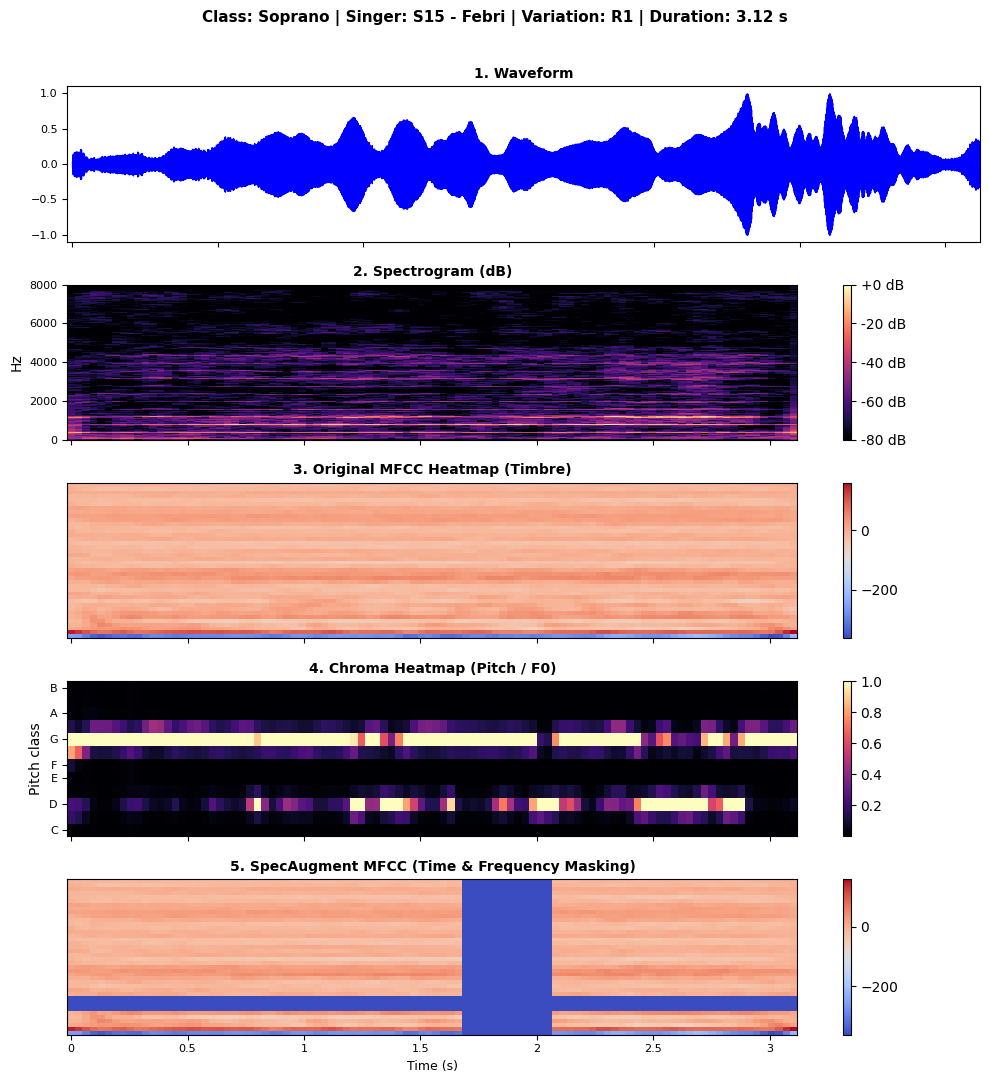


[PROCESSING CLASS: ALTO]
  ├─ Singer ID  : A09 - kk marya
  ├─ Variation  : R1
  └─ File Name  : R1_1.wav


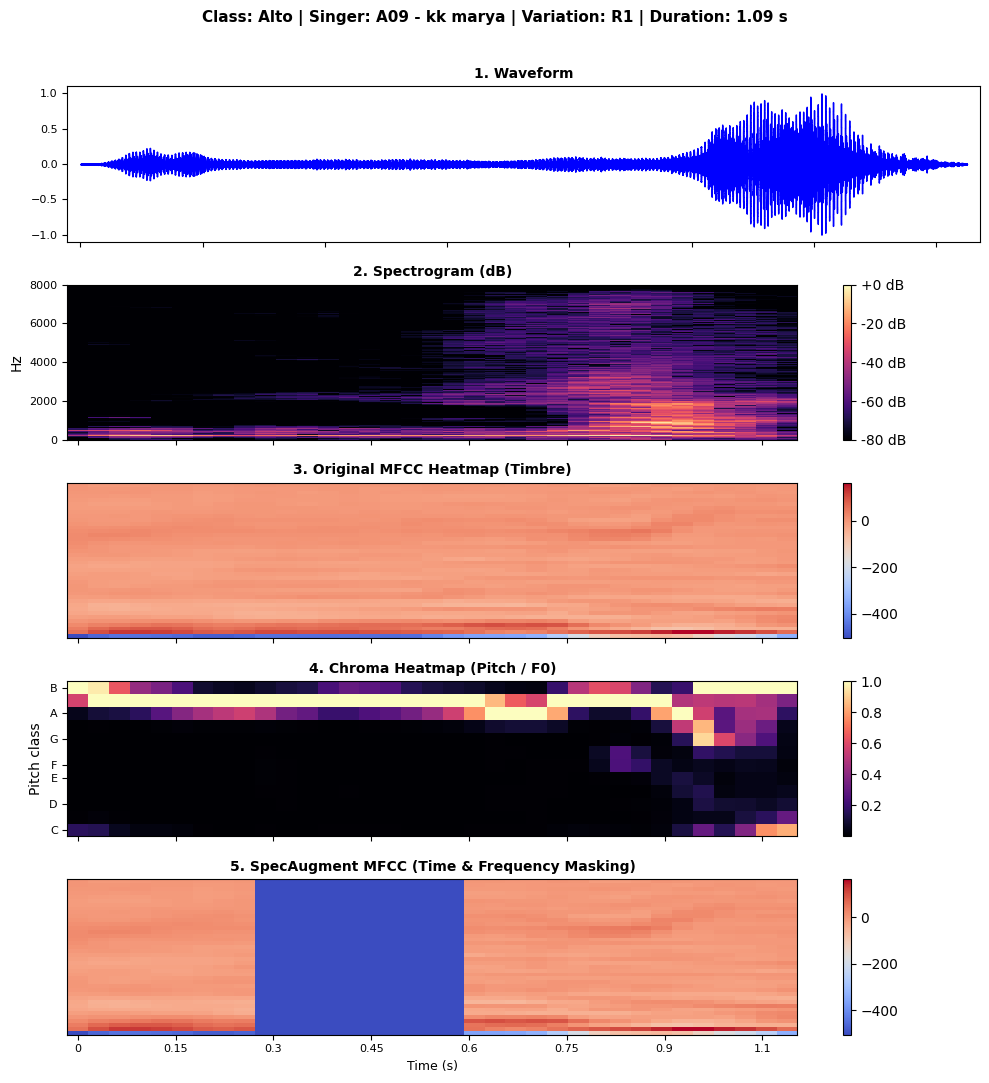


[PROCESSING CLASS: TENOR]
  ├─ Singer ID  : T08 - reno
  ├─ Variation  : R1
  └─ File Name  : R1_1.wav


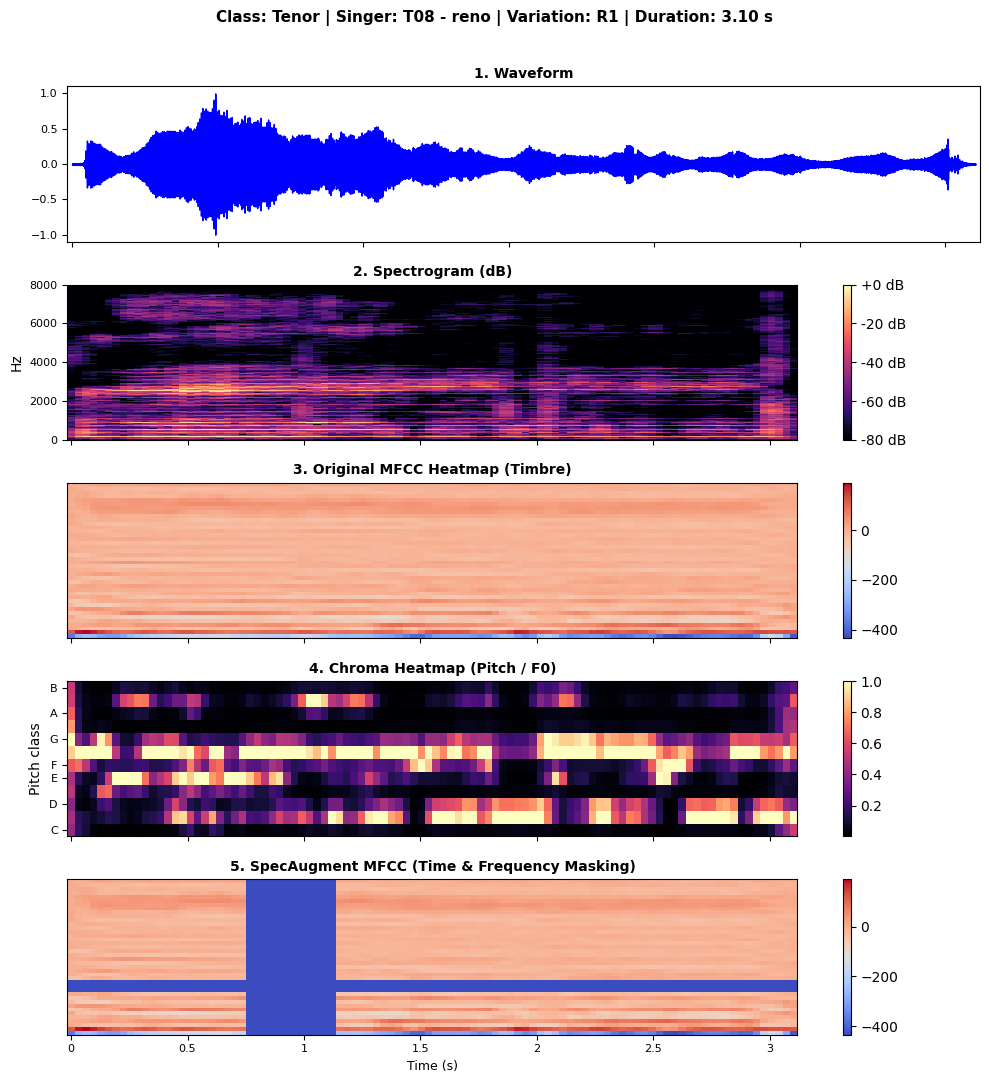


[PROCESSING CLASS: BASS]
  ├─ Singer ID  : B01 - teguh 
  ├─ Variation  : R1
  └─ File Name  : R1_1.wav


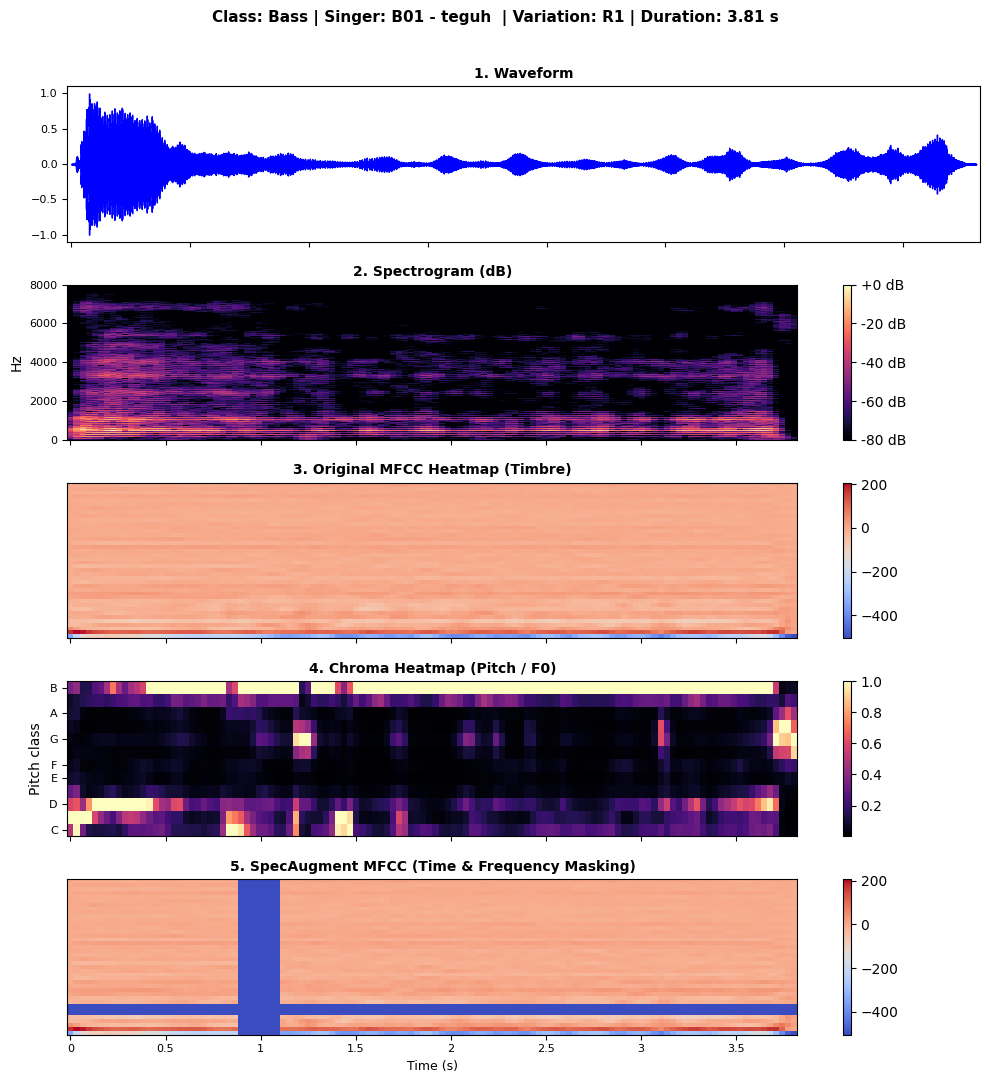

In [35]:
# ============================================================
# SECTION 2: AUDIO FEATURE VISUALIZATION (5-PANEL WITH SPECAUGMENT)
# ============================================================

import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path


def plot_audio_features(records, class_name):
    """Display 5-panel visual: Waveform, Spectrogram, MFCC, Chroma, and SpecAugment MFCC."""

    # Filter sampel original
    if "is_augmented" in records.columns:
        sample = records[
            (records["class_name"] == class_name) &
            (~records["is_augmented"])
        ]
    else:
        sample = records[records["class_name"] == class_name]

    if sample.empty:
        print(f"⚠️ No sample found for class: {class_name}")
        return

    row = sample.iloc[0]

    # Safely get values with fallbacks to avoid KeyError
    singer_id = row.get("singer_id", "Unknown")
    variation = row.get("variation", "Unknown")

    # Load audio
    file_path = Path(row["file_path"])
    audio, sr = load_audio_mono(file_path, CONFIG["sample_rate"])
    duration = len(audio) / sr

    # Computations
    stft = librosa.stft(
        audio,
        n_fft=CONFIG["n_fft"],
        hop_length=CONFIG["hop_length"],
        window=CONFIG["window"]
    )
    spectrogram = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=CONFIG["n_mfcc"],
        n_fft=CONFIG["n_fft"],
        hop_length=CONFIG["hop_length"],
        window=CONFIG["window"]
    )

    chroma = librosa.feature.chroma_stft(
        y=audio,
        sr=sr,
        n_fft=CONFIG["n_fft"],
        hop_length=CONFIG["hop_length"]
    )

    # Simulasi/Eksperimen SpecAugment pada MFCC untuk keperluan Visualisasi
    # Kembangkan dari MFCC asli dengan masking channel
    mfcc_specaug = apply_spec_augment(
        np.expand_dims(mfcc, axis=-1),  # Tambah dummy channel agar compatible
        freq_mask_max=4,
        time_mask_max=30,
        n_freq_masks=1,
        n_time_masks=1
    ).squeeze(axis=-1)

    # Figure Plotting (5-Panel Stacked)
    fig, axes = plt.subplots(5, 1, figsize=(10, 11), sharex=True)

    fig.suptitle(
        f"Class: {row['class_name']} | Singer: {singer_id} | "
        f"Variation: {variation} | Duration: {duration:.2f} s",
        fontsize=11, fontweight="bold", y=0.98
    )

    # 1. Waveform
    librosa.display.waveshow(audio, sr=sr, ax=axes[0], color="b")
    axes[0].set_title("1. Waveform", fontsize=10, fontweight="bold")
    axes[0].tick_params(labelsize=8)
    axes[0].set_xlabel("")

    # 2. Spectrogram
    img1 = librosa.display.specshow(
        spectrogram, sr=sr, hop_length=CONFIG["hop_length"],
        x_axis="time", y_axis="hz", ax=axes[1]
    )
    axes[1].set_title("2. Spectrogram (dB)", fontsize=10, fontweight="bold")
    axes[1].tick_params(labelsize=8)
    axes[1].set_xlabel("")
    fig.colorbar(img1, ax=axes[1], format="%+2.0f dB")

    # 3. MFCC Original
    img2 = librosa.display.specshow(
        mfcc, sr=sr, hop_length=CONFIG["hop_length"],
        x_axis="time", ax=axes[2]
    )
    axes[2].set_title("3. Original MFCC Heatmap (Timbre)", fontsize=10, fontweight="bold")
    axes[2].tick_params(labelsize=8)
    axes[2].set_xlabel("")
    fig.colorbar(img2, ax=axes[2])

    # 4. Chroma (F0 / Pitch)
    img3 = librosa.display.specshow(
        chroma, sr=sr, hop_length=CONFIG["hop_length"],
        x_axis="time", y_axis="chroma", ax=axes[3]
    )
    axes[3].set_title("4. Chroma Heatmap (Pitch / F0)", fontsize=10, fontweight="bold")
    axes[3].tick_params(labelsize=8)
    axes[3].set_xlabel("")
    fig.colorbar(img3, ax=axes[3])

    # 5. SpecAugment MFCC (Augmented Feature)
    img4 = librosa.display.specshow(
        mfcc_specaug, sr=sr, hop_length=CONFIG["hop_length"],
        x_axis="time", ax=axes[4]
    )
    axes[4].set_title("5. SpecAugment MFCC (Time & Frequency Masking)", fontsize=10, fontweight="bold")
    axes[4].tick_params(labelsize=8)
    axes[4].set_xlabel("Time (s)", fontsize=9)
    fig.colorbar(img4, ax=axes[4])

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    # Save Image
    save_path = PATHS["result"] / f"{class_name}_audio_features_specaug.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


# ------------------------------------------------------------
# RUN SAFE VISUALIZATION LOOP
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("GENERATING AUDIO FEATURE VISUALIZATIONS (WAVEFORM, SPEC, MFCC, CHROMA, SPECAUGMENT)")
print("=" * 70)

for class_name in CONFIG["classes"]:
    # Cek ketersediaan data sebelum memanggil plot
    if "is_augmented" in train_records.columns:
        filtered_df = train_records[
            (train_records["class_name"] == class_name) &
            (~train_records["is_augmented"])
        ]
    else:
        filtered_df = train_records[train_records["class_name"] == class_name]

    if filtered_df.empty:
        print(f"\n⚠️ WARNING: Sample not found for class '{class_name}'")
        continue

    sample = filtered_df.iloc[0]

    singer_id = sample.get("singer_id", "N/A")
    variation = sample.get("variation", "N/A")

    print(f"\n[PROCESSING CLASS: {class_name.upper()}]")
    print(f"  ├─ Singer ID  : {singer_id}")
    print(f"  ├─ Variation  : {variation}")
    print(f"  └─ File Name  : {Path(sample['file_path']).name}")

    # Panggil fungsi visualisasi
    plot_audio_features(train_records, class_name)

# Label Preparation

In [37]:
# ============================================================
# REVISED LABEL & DATASET VERIFICATION (5-CHANNEL HYBRID)
# (WITH SINGER LEAKAGE & TENSOR ALIGNMENT CHECKS)
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

print("=" * 70)
print("LABEL & DATASET VERIFICATION (5-CHANNEL HYBRID ENHANCED)")
print("=" * 70)


# ============================================================
# 1. INFORMASI DASAR DATASET
# ============================================================
print("\n1. DATASET OVERVIEW")
print("-" * 70)

if "split_df" in globals():
    print(f"Total Samples    : {len(split_df)}")
    print(f"Available Splits : {sorted(split_df['split'].unique())}")
else:
    print("⚠️ Warning: 'split_df' belum terdefinisi di RAM!")

if "CONFIG" in globals():
    print(f"Target Classes   : {CONFIG.get('classes', 'N/A')}")
    print(f"Sample Rate      : {CONFIG.get('sample_rate', 'N/A')} Hz")
    print(f"MFCC Coefficients: {CONFIG.get('n_mfcc', 'N/A')}")
    print(f"Target Frames    : {CONFIG.get('max_target_frames', 'N/A')}")


# ============================================================
# 2. DISTRIBUSI KELAS VOKAL & PENYANYI
# ============================================================
if "split_df" in globals():
    print("\n2. CLASS DISTRIBUTION PER SPLIT")
    print("-" * 70)
    class_dist = split_df.groupby(["split", "class_name"]).size().unstack(fill_value=0)
    display(class_dist)

    print("\n3. UNIQUE SINGERS PER CLASS & SPLIT")
    print("-" * 70)
    singer_dist = split_df.groupby(["split", "class_name"])["singer_id"].nunique().unstack(fill_value=0)
    display(singer_dist)

    print("\n4. SUMMARY RECORDINGS & SINGERS")
    print("-" * 70)
    summary_df = split_df.groupby(["split", "class_name"]).agg(
        recordings=("file_path", "count"),
        singers=("singer_id", "nunique")
    )
    display(summary_df)


# ============================================================
# 3. DETEKSI DATA LEAKAGE (SINGER LEAKAGE CHECK)
# ============================================================
print("\n5. SINGER LEAKAGE AUDIT (TRAIN / VAL / TEST)")
print("-" * 70)

if "split_df" in globals():
    splits = split_df["split"].unique()
    singer_sets = {s: set(split_df[split_df["split"] == s]["singer_id"].unique()) for s in splits}

    leakage_found = False
    split_names = list(singer_sets.keys())

    for i in range(len(split_names)):
        for j in range(i + 1, len(split_names)):
            s1, s2 = split_names[i], split_names[j]
            overlap = singer_sets[s1].intersection(singer_sets[s2])

            if overlap:
                leakage_found = True
                print(f"⚠️ LEAKAGE DETECTED! Overlap antara '{s1}' dan '{s2}': {len(overlap)} penyanyi")
                print(f"   Singer IDs: {sorted(list(overlap))}")

    if not leakage_found:
        print("✅ AMAN! Tidak ada penyanyi (singer_id) yang tumpang-tindih antar split dataset.")


# ============================================================
# 4. VERIFIKASI ARRAY TENSOR & FEATURE SHAPE (5-CHANNEL)
# ============================================================
print("\n6. LABEL TENSOR & 5-CHANNEL FEATURE SHAPE VERIFICATION")
print("-" * 70)

tensor_targets = [
    ("X_train", "y_train", ["train_meta", "hybrid_train_meta"]),
    ("X_val", "y_val", ["val_meta", "hybrid_val_meta"]),
    ("X_test", "y_test", ["test_meta", "hybrid_test_meta"]),
    ("X_external", "y_external", ["external_meta", "hybrid_external_meta"])
]

for x_var, y_var, meta_candidates in tensor_targets:
    if y_var in globals() and isinstance(globals()[y_var], np.ndarray):
        y_arr = globals()[y_var]
        print(f"\n📌 Partition Target: {y_var}")
        print(f"   • Label Array Shape : {y_arr.shape}")

        # Cek Shape Tensor Fitur 5 Kanal jika ada (X_train, dll)
        if x_var in globals() and isinstance(globals()[x_var], np.ndarray):
            x_arr = globals()[x_var]
            print(f"   • Feature Tensor Shape (5-Ch): {x_arr.shape}")
            if len(x_arr.shape) == 4:
                print(f"     -> Format: (Samples={x_arr.shape[0]}, Rows={x_arr.shape[1]}, Cols={x_arr.shape[2]}, Channels={x_arr.shape[3]})")

        # Konversi One-Hot ke Label Index jika 2D
        labels = np.argmax(y_arr, axis=1) if y_arr.ndim == 2 else y_arr
        unique_labels, counts = np.unique(labels, return_counts=True)

        # Cek Mapping ke Nama Kelas jika CONFIG tersedia
        if "CONFIG" in globals():
            class_counts = {CONFIG["classes"][idx]: count for idx, count in zip(unique_labels, counts)}
            print(f"   • Class Distribution : {class_counts}")
        else:
            print(f"   • Index Distribution : {dict(zip(unique_labels, counts))}")

        # Cek Sinkronisasi dengan Metadata DataFrame
        meta_found = False
        for meta_var in meta_candidates:
            if meta_var in globals() and isinstance(globals()[meta_var], pd.DataFrame):
                meta_len = len(globals()[meta_var])
                meta_found = True
                if meta_len == len(y_arr):
                    print(f"   • Metadata ({meta_var}) Align : ✅ PRESISI ({meta_len} baris)")
                else:
                    print(f"   • Metadata ({meta_var}) Align : ❌ MISMATCH! Tensor ({len(y_arr)}) vs Metadata ({meta_len})")
                break

        if not meta_found:
            print("   • Metadata Align : ℹ️ Variabel metadata dataframe tidak ditemukan di RAM.")


# ============================================================
# 5. CLASS MAPPING DI RAM
# ============================================================
print("\n7. CLASS MAPPING VARIABLES IN RAM")
print("-" * 70)

mapping_vars = ["LABEL_TO_INDEX", "INDEX_TO_LABEL", "label_encoder", "class_mapping"]
found_mapping = False

for var_name in mapping_vars:
    if var_name in globals():
        found_mapping = True
        print(f"• {var_name}: {globals()[var_name]}")

if not found_mapping:
    print("ℹ️ Variable mapping umum (seperti LABEL_TO_INDEX) tidak ditemukan secara spesifik.")


# ============================================================
# 6. DATA QUALITY AUDIT (DISTRIBUSI FILE PER PENYANYI)
# ============================================================
print("\n8. DATA QUALITY CHECK (FILES PER SINGER)")
print("-" * 70)

if "split_df" in globals():
    files_per_singer = (
        split_df.groupby(["split", "class_name", "singer_id"])
        .size()
        .reset_index(name="num_files")
    )

    few_files = files_per_singer[files_per_singer["num_files"] < 20]

    if few_files.empty:
        print("✅ Sempurna! Semua penyanyi memiliki minimal 20 file rekaman.")
    else:
        print(f"⚠️ Ditemukan {len(few_files)} penyanyi dengan jumlah file < 20:")
        display(few_files)

print("\n" + "=" * 70)
print("VERIFICATION COMPLETED SUCCESSFULLY")
print("=" * 70)

LABEL & DATASET VERIFICATION (5-CHANNEL HYBRID ENHANCED)

1. DATASET OVERVIEW
----------------------------------------------------------------------
Total Samples    : 1581
Available Splits : ['test', 'train', 'validation']
Target Classes   : ['Soprano', 'Alto', 'Tenor', 'Bass']
Sample Rate      : 16000 Hz
MFCC Coefficients: 40
Target Frames    : 700

2. CLASS DISTRIBUTION PER SPLIT
----------------------------------------------------------------------


class_name,Alto,Bass,Soprano,Tenor
split,,,,
test,65,72,66,66
train,250,261,254,235
validation,78,82,79,73



3. UNIQUE SINGERS PER CLASS & SPLIT
----------------------------------------------------------------------


class_name,Alto,Bass,Soprano,Tenor
split,,,,
test,3,3,3,3
train,13,12,13,13
validation,4,4,4,4



4. SUMMARY RECORDINGS & SINGERS
----------------------------------------------------------------------


recordings  singers
split      class_name                     
test       Alto                65        3
           Bass                72        3
           Soprano             66        3
           Tenor               66        3
train      Alto               250       13
           Bass               261       12
           Soprano            254       13
           Tenor              235       13
validation Alto                78        4
           Bass                82        4
           Soprano             79        4
           Tenor               73        4


5. SINGER LEAKAGE AUDIT (TRAIN / VAL / TEST)
----------------------------------------------------------------------
✅ AMAN! Tidak ada penyanyi (singer_id) yang tumpang-tindih antar split dataset.

6. LABEL TENSOR & 5-CHANNEL FEATURE SHAPE VERIFICATION
----------------------------------------------------------------------

📌 Partition Target: y_train
   • Label Array Shape : (1996, 4)
   • Feature Tensor Shape (5-Ch): (1996, 40, 358, 4)
     -> Format: (Samples=1996, Rows=40, Cols=358, Channels=4)
   • Class Distribution : {'Soprano': np.int64(508), 'Alto': np.int64(496), 'Tenor': np.int64(470), 'Bass': np.int64(522)}
   • Metadata (train_meta) Align : ✅ PRESISI (1996 baris)

📌 Partition Target: y_val
   • Label Array Shape : (311, 4)
   • Feature Tensor Shape (5-Ch): (311, 40, 358, 4)
     -> Format: (Samples=311, Rows=40, Cols=358, Channels=4)
   • Class Distribution : {'Soprano': np.int64(78), 'Alto': np.int64(78), 'Tenor': np.int64(73), 'Bass': np.int64(82)}
   • Metadata (val_meta

,split,class_name,singer_id,num_files
12,train,Alto,A01,12
15,train,Alto,A03,12
17,train,Alto,A04,12
22,train,Alto,A13 - kk tania,16
24,train,Alto,A15 - suri,18
25,train,Bass,B01,12
28,train,Bass,B03,12
30,train,Bass,B04,12
38,train,Soprano,S02,12
40,train,Soprano,S03,12



VERIFICATION COMPLETED SUCCESSFULLY


# 11-3 MFCC Similarity Analysis


GENERATING REVISED FEATURE SIMILARITY HEATMAP


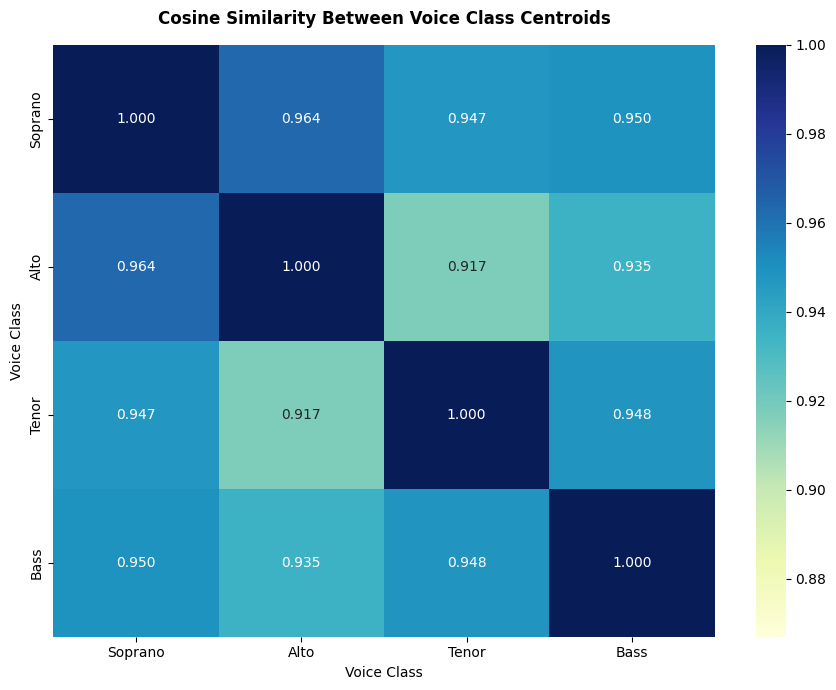

In [38]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# REVISI: FEATURE SIMILARITY HEATMAP (CENTROID & TIME-POOLING)
# ============================================================

def plot_robust_feature_similarity(X_train, y_train, class_names):
    """
    Menghitung dan memvisualisasikan Cosine Similarity yang benar
    menggunakan metode Time-Pooling dan Class Centroids.

    Asumsi shape X_train: (Samples, Features, TimeFrames, Channels)
    Asumsi shape y_train: (Samples, NumClasses) -> One-Hot Encoded
    """

    # 1. GLOBAL AVERAGE POOLING PADA SUMBU WAKTU (Time-Pooling)
    # Jika X_train shape-nya (N, 40, 150, 4), axis waktu biasanya di index 2 (150).
    # Kita rata-rata sumbu waktu agar menghasilkan shape (N, 40, 4).
    # Catatan: Sesuaikan axis=2 jika urutan dimensi Anda berbeda (misal: N, Frames, Features, Channels)
    time_axis = 2 if X_train.shape[1] < X_train.shape[2] else 1
    X_pooled = np.mean(X_train, axis=time_axis)

    # 2. FLATTEN SISA DIMENSI
    # Ubah menjadi 2D matrix (Samples, Flattened_Features) -> (N, 40 * 4) = (N, 160)
    X_flat = X_pooled.reshape(X_pooled.shape[0], -1)

    # 3. MENGHITUNG VEKTOR INTI (CENTROID) PER KELAS
    centroids = []

    # Konversi y_train dari one-hot ke label integer (0, 1, 2, 3)
    if y_train.ndim > 1 and y_train.shape[1] > 1:
        y_labels = np.argmax(y_train, axis=1)
    else:
        y_labels = y_train

    for i in range(len(class_names)):
        # Ambil semua vektor yang masuk dalam kelas ke-i
        class_vectors = X_flat[y_labels == i]

        # Hitung rata-rata semua vektor tersebut untuk mendapat 1 vektor Centroid
        centroid = np.mean(class_vectors, axis=0)
        centroids.append(centroid)

    centroids = np.array(centroids)

    # 4. HITUNG COSINE SIMILARITY ANTAR CENTROID
    # Menghasilkan matriks (4, 4) untuk 4 kelas (Soprano, Alto, Tenor, Bass)
    sim_matrix = cosine_similarity(centroids)

    # 5. VISUALISASI HEATMAP
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        sim_matrix,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        xticklabels=class_names,
        yticklabels=class_names,
        vmin=np.min(sim_matrix) - 0.05, # Menyesuaikan kontras warna agar lebih tajam
        vmax=1.0
    )

    plt.title("Cosine Similarity Between Voice Class Centroids", fontsize=12, fontweight="bold", pad=15)
    plt.xlabel("Voice Class", fontsize=10)
    plt.ylabel("Voice Class", fontsize=10)
    plt.tight_layout()
    plt.show()

# PANGGIL FUNGSI (Pastikan variabel X_train, y_train, dan CONFIG["classes"] sudah di-load)
print("\n" + "=" * 60)
print("GENERATING REVISED FEATURE SIMILARITY HEATMAP")
print("=" * 60)
plot_robust_feature_similarity(X_train, y_train, CONFIG["classes"])

# Visualisasi Outlier Penyanyi

In [39]:
# ============================================================
# SECTION 4: t-SNE VISUALIZATION & OUTLIER ANALYSIS (SATB)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

print("=" * 75)
print("VISUALISASI t-SNE & DETEKSI OUTLIER PENYANYI (MFCC + CHROMA)")
print("=" * 75)

# ------------------------------------------------------------
# STEP PREPARATION: MENGAMBIL/MEMBUAT SINGER EMBEDDINGS (TIME-POOLED)
# ------------------------------------------------------------
if "singer_embeddings" not in globals() or "singer_info" not in globals():
    print("⏳ Menyiapkan singer_embeddings & singer_info dari dataset...")

    # 1. Load Data
    tensor_path = PATHS["result"] / "hybrid_features_tensors.npz"
    data = np.load(tensor_path)
    X_all = np.concatenate([data["X_train"], data["X_val"], data["X_test"]], axis=0)

    # Gabungkan metadata dan reset index
    meta_df = pd.concat([train_meta, val_meta, test_meta], ignore_index=True)

    # 2. Filter Data (Hanya gunakan suara asli, buang SpecAugment jika ada)
    # Gunakan 'is_specaug' atau 'is_augmented' sesuai nama kolom Anda
    if "is_specaug" in meta_df.columns:
        clean_mask = ~meta_df["is_specaug"].astype(bool)
    elif "is_augmented" in meta_df.columns:
        clean_mask = ~meta_df["is_augmented"].astype(bool)
    else:
        clean_mask = pd.Series(True, index=meta_df.index)

    meta_clean = meta_df[clean_mask].reset_index(drop=True)
    X_clean = X_all[clean_mask]

    # Pastikan ketersediaan kolom singer_id
    if "singer_id" not in meta_clean.columns:
        meta_clean["singer_id"] = meta_clean.index.map(lambda x: f"S_{x:03d}")

    # 3. GLOBAL AVERAGE POOLING (MENGHILANGKAN DIMENSI WAKTU/PADDING)
    # Asumsi shape X_clean: (Samples, Features/MFCC, TimeFrames, Channels)
    time_axis = 2 if X_clean.shape[1] < X_clean.shape[2] else 1
    X_pooled = np.mean(X_clean, axis=time_axis)

    # 4. FLATTEN HANYA FITUR DAN CHANNEL -> Shape menjadi (Samples, Features * Channels)
    X_data = X_pooled.reshape(X_pooled.shape[0], -1)

    # 5. Agregasi Fitur Rata-rata per Penyanyi (Singer Embedding)
    grouped_embeddings = []
    grouped_info = []

    for (s_id, c_name), group in meta_clean.groupby(["singer_id", "class_name"]):
        group_indices = group.index.values

        if len(group_indices) > 0:
            # Rata-rata semua sampel audio milik 1 penyanyi menjadi 1 titik vektor
            singer_avg_feat = np.mean(X_data[group_indices], axis=0)
            grouped_embeddings.append(singer_avg_feat)
            grouped_info.append({"singer_id": s_id, "class_name": c_name})

    singer_embeddings = np.array(grouped_embeddings)
    singer_info = pd.DataFrame(grouped_info)

n_singers = len(singer_info)
print(f"✅ Total Penyanyi Teridentifikasi (Original Data): {n_singers}")

# ------------------------------------------------------------
# PEMROSESAN t-SNE DAN OUTLIER ANALYSIS
# ------------------------------------------------------------
if n_singers < 3:
    print("⚠️ Jumlah penyanyi terlalu sedikit untuk analisis t-SNE dan k-NN.")
else:
    # ------------------------------------------------------------
    # 1. Jalankan t-SNE (2D) dengan Perplexity Dinamis (Aman)
    # ------------------------------------------------------------
    # Perplexity disesuaikan agar tidak melebihi jumlah sampel
    dynamic_perplexity = min(30, max(2, (n_singers - 1) // 3))

    tsne = TSNE(
        n_components=2,
        perplexity=dynamic_perplexity,
        random_state=42,
        init='pca',
        learning_rate='auto'
    )
    embeddings_2d = tsne.fit_transform(singer_embeddings)

    singer_info["tsne_x"] = embeddings_2d[:, 0]
    singer_info["tsne_y"] = embeddings_2d[:, 1]

    # ------------------------------------------------------------
    # 2. Buat Plot Visualisasi t-SNE Seluruh Kelas
    # ------------------------------------------------------------
    plt.figure(figsize=(12, 8))
    ax = sns.scatterplot(
        data=singer_info,
        x="tsne_x",
        y="tsne_y",
        hue="class_name",
        style="class_name",
        s=150,
        palette="Set1",
        alpha=0.9
    )

    # Label ID Penyanyi
    for idx, row in singer_info.iterrows():
        ax.annotate(
            str(row["singer_id"]),
            (row["tsne_x"], row["tsne_y"]),
            xytext=(6, -2),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
            alpha=0.85
        )

    plt.title(
        f"Proyeksi t-SNE Singer Embeddings (MFCC + Chroma) | Perplexity={dynamic_perplexity}",
        fontsize=13,
        fontweight="bold"
    )
    plt.xlabel("t-SNE Dimensi 1", fontsize=10)
    plt.ylabel("t-SNE Dimensi 2", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(title="Voice Class", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()

    # Simpan Plot
    save_path = PATHS["result"] / "tsne_all_classes_outliers_chroma.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # ------------------------------------------------------------
    # 3. ANALISIS OTOMATIS OUTLIER UNTUK SETIAP KELAS (S, A, T, B)
    # ------------------------------------------------------------
    print("\n" + "=" * 75)
    print("LAPORAN DETEKSI OUTLIER PENYANYI (SEMUA KELAS VOKAL)")
    print("=" * 75)

    # Tetapkan k-NN dinamis (Maksimal 4 tetangga terdekat)
    k_neighbors = min(5, n_singers) # Set 5 (termasuk dirinya sendiri)
    nn = NearestNeighbors(n_neighbors=k_neighbors)
    nn.fit(singer_embeddings)
    distances, indices = nn.kneighbors(singer_embeddings)

    all_confused = {}
    total_outliers = 0

    # Iterasi untuk SETIAP kelas vokal (Soprano, Alto, Tenor, Bass)
    for target_class in CONFIG["classes"]:
        class_indices = singer_info[singer_info["class_name"] == target_class].index
        class_outliers = []

        print(f"\n📌 ANALISIS KELAS: {target_class.upper()}")
        print("-" * 50)

        if len(class_indices) == 0:
            print(f"⚠️ Tidak ada data penyanyi untuk kelas {target_class}.")
            continue

        for idx in class_indices:
            s_id = singer_info.iloc[idx]["singer_id"]

            # Ambil tetangga terdekat (mengabaikan dirinya sendiri di indeks 0)
            neighbor_idxs = indices[idx][1:]
            neighbor_classes = singer_info.iloc[neighbor_idxs]["class_name"].tolist()
            neighbor_ids = singer_info.iloc[neighbor_idxs]["singer_id"].tolist()

            # Hitung berapa tetangga yang BUKAN dari kelas aslinya
            non_class_count = sum(1 for c in neighbor_classes if c != target_class)

            # Jika mayoritas tetangga adalah kelas lain -> OUTLIER
            threshold = len(neighbor_classes) / 2.0
            if non_class_count > threshold:
                class_outliers.append(s_id)
                total_outliers += 1
                print(f"⚠️  Singer ID '{s_id}'")
                print(f"    --> Tetangga Terdekat : {list(zip(neighbor_ids, neighbor_classes))}")
                overlapping = list(set(neighbor_classes) - {target_class})
                print(f"    --> Nyasar ke Area   : {overlapping}")

        if len(class_outliers) == 0:
            print(f"✅ Aman! Semua penyanyi {target_class} berkumpul rapi di kelompoknya.")
        else:
            print(f"--> Total Outlier {target_class}: {len(class_outliers)} penyanyi {class_outliers}")

        all_confused[target_class] = class_outliers

    # ------------------------------------------------------------
    # 4. RINGKASAN & REKOMENDASI TINDAKAN
    # ------------------------------------------------------------
    print("\n" + "=" * 75)
    print("RINGKASAN & REKOMENDASI TINDAKAN (EVALUASI MFCC + CHROMA)")
    print("=" * 75)
    print(f"• Total Penyanyi Bermasalah (Outlier): {total_outliers} dari {n_singers} penyanyi.\n")

    if total_outliers == 0:
        print("🎉 Sempurna! Fitur MFCC + Chroma berhasil memisahkan seluruh kelas vokal SATB dengan sangat jelas.")
        print("   Dataset siap digunakan untuk pelatihan model CNN/Transformer tanpa penanganan khusus.")
    elif total_outliers <= 4:
        print("💡 Outlier tergolong SEDIKIT (≤ 4 penyanyi).")
        print("   MFCC + Chroma sudah bekerja dengan sangat baik secara umum.")
        print("   TINDAKAN: Lakukan audit manual pada file audio dari Singer ID di atas.")
        print("   Periksa apakah audionya memiliki noise tinggi, nada fals, atau salah label.")
    else:
        print("⚠️ Outlier CUKUP BANYAK (> 4 penyanyi).")
        print("   Meskipun sudah ditambah fitur Chroma (pitch), beberapa sampel vokal masih saling bertumpukan.")
        print("   TINDAKAN REKOMENDASI:")
        print("   1. Audit distribusi rentang nada (pitch range) pada penyanyi yang saling overlap.")
        print("   2. Pertimbangkan menambahkan fitur 'Pitch Contour / F0 (pYIN/SWIPE)' atau Spectral Centroid.")
        print("   3. Gunakan teknik Loss Function khusus (seperti Triplet Loss / ArcFace) pada model klasifikasi nanti.")

    print("=" * 75)

VISUALISASI t-SNE & DETEKSI OUTLIER PENYANYI (MFCC + CHROMA)
⏳ Menyiapkan singer_embeddings & singer_info dari dataset...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SATB_Model/Result/hybrid_features_tensors.npz'

# 12. CNN Training

Bagian ini melatih CNN TensorFlow Keras sesuai arsitektur penelitian: tiga blok Conv2D dengan Batch Normalization, ReLU, MaxPooling/Dropout pada dua blok pertama, lalu Dense 128 dan output Softmax empat kelas. Optimizer yang digunakan adalah Adam learning rate 0.001, loss Categorical Crossentropy, maksimum 100 epoch, batch size 32, serta callback EarlyStopping, ReduceLROnPlateau, dan ModelCheckpoint.


In [40]:
# ============================================================
# REVISED CNN TRAINING (STABLE & SMOOTH VALIDATION)
# ============================================================

import json
import pickle
import logging
import numpy as np
import pandas as pd
import tensorflow as tf
from typing import Tuple
from tensorflow.keras import layers, models, callbacks, optimizers, losses, regularizers, mixed_precision

# Enable Mixed Precision
mixed_precision.set_global_policy("mixed_float16")

SEED = 42
tf.keras.utils.set_random_seed(SEED)

try:
    for gpu in tf.config.list_physical_devices("GPU"):
        tf.config.experimental.set_memory_growth(gpu, True)
except Exception:
    pass


def build_cnn_model(input_shape: Tuple[int, int, int], num_classes: int) -> tf.keras.Model:
    """
    Builds a robust 2D CNN architecture optimized for
    MFCC + Chroma audio tensors (52 x Frames x 3).
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(
            32, (3, 3),
            padding="same",
            use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.SpatialDropout2D(0.15),  # Lebih stabil untuk spectrogram/tensor audio

        # Block 2
        layers.Conv2D(
            64, (3, 3),
            padding="same",
            use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.SpatialDropout2D(0.20),

        # Block 3
        layers.Conv2D(
            128, (3, 3),
            padding="same",
            use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.SpatialDropout2D(0.25),

        # Global Pooling & Dense Classifier
        layers.GlobalAveragePooling2D(),

        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        layers.BatchNormalization(),
        layers.Dropout(0.30),

        # Output Layer (Float32 wajib untuk Mixed Precision Softmax)
        layers.Dense(
            num_classes,
            activation="softmax",
            dtype="float32"
        )
    ])

    # Optimizer dengan Clipnorm untuk mencegah grafik drop tajam
    init_lr = CONFIG.get("learning_rate", 5e-4)
    optimizer = optimizers.Adam(
        learning_rate=init_lr,
        clipnorm=1.0  # Menstabilkan lonjakan gradien
    )

    model.compile(
        optimizer=optimizer,
        loss=losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"],
        jit_compile=False
    )

    return model


def prepare_dataset(X, y, batch_size, training=True):
    """
    Fixed tf.data pipeline without caching bugs.
    """
    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if training:
        ds = ds.shuffle(
            buffer_size=min(len(X), 10000),
            reshuffle_each_iteration=True
        )

    ds = ds.batch(batch_size)
    # Removing .cache() to prevent locked-shuffle state on in-memory arrays
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


# ------------------------------------------------------------
# TRAINING EXECUTION
# ------------------------------------------------------------
try:
    model = build_cnn_model(
        X_train.shape[1:],
        len(CONFIG["classes"])
    )

    model.summary()

    batch_size = CONFIG.get("batch_size", 32)
    train_ds = prepare_dataset(X_train, y_train, batch_size, training=True)
    val_ds = prepare_dataset(X_val, y_val, batch_size, training=False)

    best_model_path = PATHS["model"] / "cnn_satb_best.keras"
    final_model_path = PATHS["model"] / "cnn_satb.keras"

    callback_list = [
        # Menghindarkan pengereman grafik dan overfitting
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        # Menurunkan LR saat val_loss stagnan agar kurva makin halus
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=best_model_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CONFIG["epochs"],
        callbacks=callback_list,
        verbose=1
    )

    # Save Models & Metadata
    best_model = tf.keras.models.load_model(best_model_path)
    best_model.save(final_model_path, include_optimizer=False)

    history_df = pd.DataFrame(history.history)
    history_df.to_csv(PATHS["result"] / "training_history.csv", index=False)

    with open(PATHS["model"] / "history.pkl", "wb") as f:
        pickle.dump(history.history, f)

    model_metadata = {
        "classes": CONFIG["classes"],
        "label_to_index": LABEL_TO_INDEX,
        "index_to_label": INDEX_TO_LABEL,
        "sample_rate": CONFIG["sample_rate"],
        "trim_top_db": CONFIG["trim_top_db"],
        "n_mfcc": CONFIG["n_mfcc"],
        "n_fft": CONFIG["n_fft"],
        "hop_length": CONFIG["hop_length"],
        "window": CONFIG["window"],
        "target_frames": int(target_frames),
        "mean": float(mean),
        "std": float(std)
    }

    with open(PATHS["model"] / "model_metadata.json", "w", encoding="utf-8") as f:
        json.dump(model_metadata, f, indent=4)

    logging.info("CNN training completed successfully.")

    print("\n" + "=" * 60)
    print("CNN TRAINING COMPLETED SUCCESSFULLY")
    print("=" * 60)
    print(f"Best Model : {best_model_path}")
    print(f"Final Model: {final_model_path}")
    print(f"Metadata   : {PATHS['model'] / 'model_metadata.json'}")
    print("=" * 60)

except Exception as stage_exc:
    logging.exception("CNN training stage failed.")
    raise RuntimeError(f"CNN training failed: {stage_exc}") from stage_exc

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 40, 358, 32)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 358, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 40, 358, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 179, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 20, 179, 32)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 179, 64)    │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20, 179, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 20, 179, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 89, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_4             │ (None, 10, 89, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 89, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 89, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 10, 89, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_5             │ (None, 10, 89, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,980 (402.27 KB)

 Trainable params: 102,404 (400.02 KB)

 Non-trainable params: 576 (2.25 KB)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2107 - loss: 1.8023
Epoch 1: val_loss improved from None to 1.42032, saving model to /content/drive/MyDrive/SATB_Model/Model/cnn_satb_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SATB_Model/Model/cnn_satb_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.2300 - loss: 1.6755 - val_accuracy: 0.2637 - val_loss: 1.4203 - learning_rate: 0.0050
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2686 - loss: 1.5072
Epoch 2: val_loss improved from 1.42032 to 1.41947, saving model to /content/drive/MyDrive/SATB_Model/Model/cnn_satb_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SATB_Model/Model/cnn_satb_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.2580 - loss: 1.4923 - val_accuracy: 0.2508 - val_loss: 1.4195 - learning_rate: 0.0050
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2393 - loss: 1.4850
Epoch 3: val_loss i

# 13. Model Evaluation

Bagian ini mengevaluasi model pada test set internal. Metrik yang dihitung meliputi accuracy, precision, recall, F1-score, confusion matrix, dan classification report. Plot training accuracy, training loss, dan confusion matrix disimpan ke folder `Result/`.


2026-09-15 12:56:34,303 | INFO | Loaded best model from /content/drive/MyDrive/SATB_Model/Model/cnn_satb_best.keras


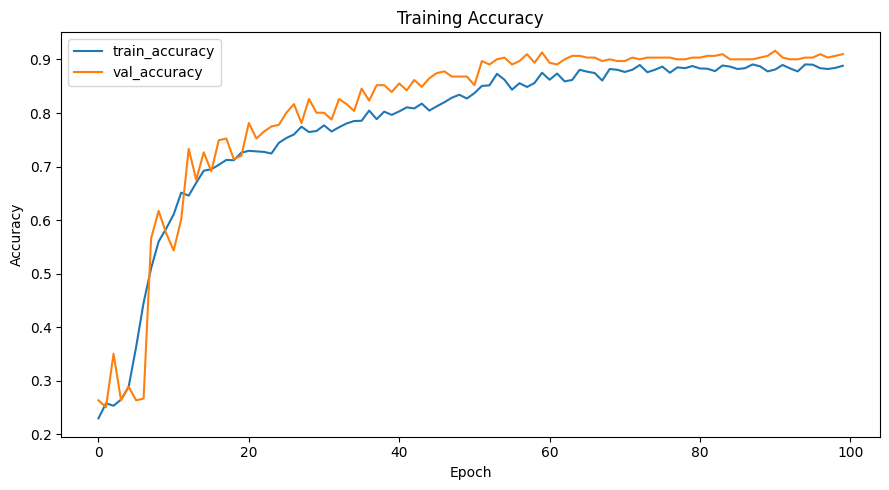

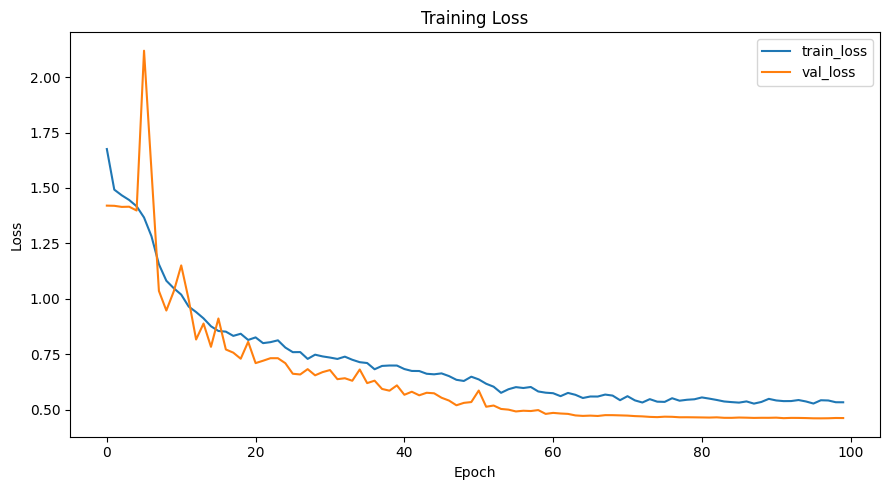

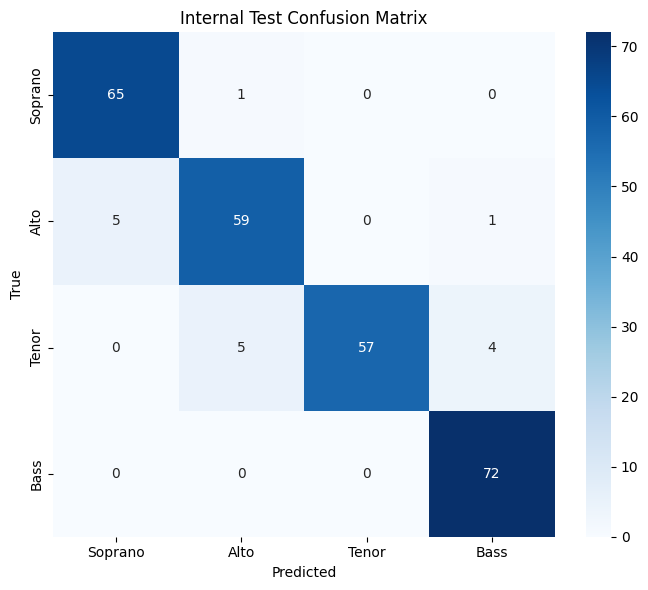

Inference time: 0.7585 seconds (2.8197 ms/sample)
{
  "status": "ok",
  "accuracy": 0.9405204460966543,
  "precision_macro": 0.9428321678321678,
  "recall_macro": 0.939044289044289,
  "f1_macro": 0.9392117204865753,
  "total_inference_time_seconds": 0.7585050420002517,
  "average_inference_time_seconds": 0.0028197213457258428,
  "average_inference_time_ms": 2.819721345725843,
  "samples_tested": 269
}
              precision    recall  f1-score   support

     Soprano       0.93      0.98      0.96        66
        Alto       0.91      0.91      0.91        65
       Tenor       1.00      0.86      0.93        66
        Bass       0.94      1.00      0.97        72

    accuracy                           0.94       269
   macro avg       0.94      0.94      0.94       269
weighted avg       0.94      0.94      0.94       269



In [41]:
import time

def plot_training_history(history_df: pd.DataFrame) -> None:
    """Plot and save training accuracy and loss curves."""
    if history_df.empty:
        logging.warning("Training history is empty; skipping training plots.")
        return
    if "accuracy" in history_df.columns:
        plt.figure(figsize=(9, 5))
        plt.plot(history_df["accuracy"], label="train_accuracy")
        if "val_accuracy" in history_df.columns:
            plt.plot(history_df["val_accuracy"], label="val_accuracy")
        plt.title("Training Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.tight_layout()
        plt.savefig(PATHS["result"] / "training_accuracy.png", dpi=160)
        plt.savefig(PATHS["result"] / "accuracy.png", dpi=160)
        plt.show()
    if "loss" in history_df.columns:
        plt.figure(figsize=(9, 5))
        plt.plot(history_df["loss"], label="train_loss")
        if "val_loss" in history_df.columns:
            plt.plot(history_df["val_loss"], label="val_loss")
        plt.title("Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.tight_layout()
        plt.savefig(PATHS["result"] / "training_loss.png", dpi=160)
        plt.savefig(PATHS["result"] / "loss.png", dpi=160)
        plt.show()

def evaluate_classifier(model: tf.keras.Model, X: np.ndarray, y: np.ndarray, metadata: pd.DataFrame, prefix: str) -> Dict[str, Any]:
    """Evaluate a classifier and save metrics, classification report, and confusion matrix."""
    if X.shape[0] == 0:
        logging.warning("%s evaluation skipped because tensor is empty.", prefix)
        return {"status": "skipped_empty_dataset"}

    # ==========================
    # INFERENCE TIME MEASUREMENT
    # ==========================
    start_time = time.perf_counter()

    probabilities = model.predict(X, verbose=0)

    end_time = time.perf_counter()

    total_inference_time = end_time - start_time
    average_inference_time = total_inference_time / X.shape[0]

    y_pred = np.argmax(probabilities, axis=1)
    y_true = np.argmax(y, axis=1)

    metrics = {
        "status": "ok",
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),

        # Inference Time
        "total_inference_time_seconds": float(total_inference_time),
        "average_inference_time_seconds": float(average_inference_time),
        "average_inference_time_ms": float(average_inference_time * 1000),
        "samples_tested": int(X.shape[0]),
    }
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(CONFIG["classes"]))),
        target_names=CONFIG["classes"],
        zero_division=0,
        output_dict=True,
    )
    report_text = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(CONFIG["classes"]))),
        target_names=CONFIG["classes"],
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CONFIG["classes"]))))

    with open(PATHS["result"] / f"{prefix}_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)
    if prefix == "external_test":
        pd.DataFrame([metrics]).to_csv(PATHS["result"] / "external_test.csv", index=False)
    pd.DataFrame(report_dict).transpose().to_csv(PATHS["result"] / f"{prefix}_classification_report.csv")
    pd.DataFrame(cm, index=CONFIG["classes"], columns=CONFIG["classes"]).to_csv(PATHS["result"] / f"{prefix}_confusion_matrix.csv")
    if prefix == "internal_test":
        pd.DataFrame(report_dict).transpose().to_csv(PATHS["result"] / "classification_report.csv")
        pd.DataFrame(cm, index=CONFIG["classes"], columns=CONFIG["classes"]).to_csv(PATHS["result"] / "confusion_matrix.csv")

    predictions_df = metadata.copy().reset_index(drop=True)
    predictions_df["true_label"] = [INDEX_TO_LABEL[int(i)] for i in y_true]
    predictions_df["predicted_label"] = [INDEX_TO_LABEL[int(i)] for i in y_pred]
    predictions_df["confidence"] = probabilities.max(axis=1)
    predictions_df.to_csv(PATHS["result"] / f"{prefix}_predictions.csv", index=False)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CONFIG["classes"], yticklabels=CONFIG["classes"])
    plt.title(f"{prefix.replace('_', ' ').title()} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(PATHS["result"] / f"{prefix}_confusion_matrix.png", dpi=160)
    if prefix == "internal_test":
        plt.savefig(PATHS["result"] / "confusion_matrix.png", dpi=160)
    plt.show()

    print(
    f"Inference time: {total_inference_time:.4f} seconds "
    f"({average_inference_time*1000:.4f} ms/sample)")
    print(json.dumps(metrics, indent=2))
    print(report_text)
    return metrics

try:
    best_model_path = PATHS["model"] / "cnn_satb_best.keras"
    if best_model_path.exists():
        model = tf.keras.models.load_model(best_model_path)
        logging.info("Loaded best model from %s", best_model_path)

    plot_training_history(history_df)

    # PERBAIKAN: Definisikan mfcc_test_meta dari split_df sebelum evaluasi
    mfcc_test_meta = split_df[split_df["split"] == "test"].reset_index(drop=True)

    internal_test_metrics = evaluate_classifier(model, X_test, y_test, mfcc_test_meta, "internal_test")
except Exception as stage_exc:
    logging.exception("Model evaluation stage failed.")
    raise RuntimeError(f"Model evaluation failed: {stage_exc}") from stage_exc

# 14. External Dataset Testing

Bagian ini mengevaluasi model terlatih pada seluruh dataset eksternal. Dataset eksternal tidak pernah digunakan pada training, validation, maupun test internal. Metrik evaluasi eksternal dihitung ulang dan disimpan sebagai artefak terpisah.


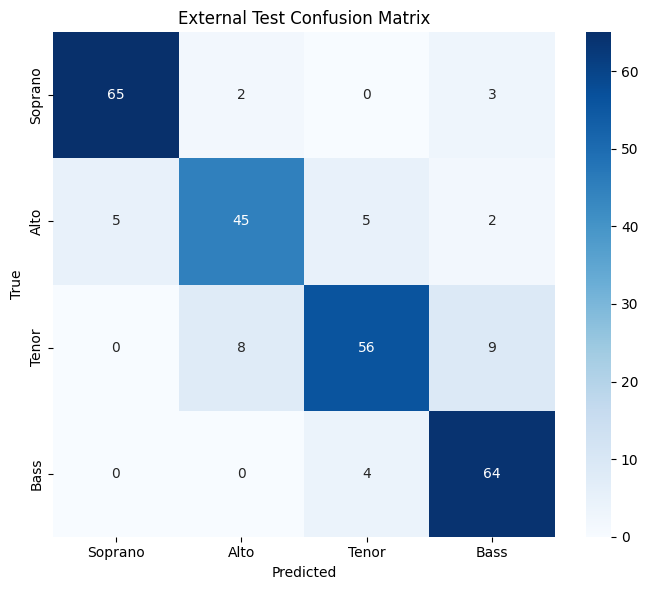

Inference time: 0.4262 seconds (1.5904 ms/sample)
{
  "status": "ok",
  "accuracy": 0.8582089552238806,
  "precision_macro": 0.8572011322011321,
  "recall_macro": 0.8565862177603558,
  "f1_macro": 0.8551123472021328,
  "total_inference_time_seconds": 0.42623050400015927,
  "average_inference_time_seconds": 0.0015904123283588033,
  "average_inference_time_ms": 1.5904123283588032,
  "samples_tested": 268
}
              precision    recall  f1-score   support

     Soprano       0.93      0.93      0.93        70
        Alto       0.82      0.79      0.80        57
       Tenor       0.86      0.77      0.81        73
        Bass       0.82      0.94      0.88        68

    accuracy                           0.86       268
   macro avg       0.86      0.86      0.86       268
weighted avg       0.86      0.86      0.86       268



In [42]:
try:
    external_metrics = evaluate_classifier(model, X_external, y_external, external_meta, "external_test")
except Exception as stage_exc:
    logging.exception("External dataset testing stage failed.")
    raise RuntimeError(f"External dataset testing failed: {stage_exc}") from stage_exc


2026-09-15 12:57:08,633 | INFO | Loaded model from /content/drive/MyDrive/SATB_Model/Model/cnn_satb.keras


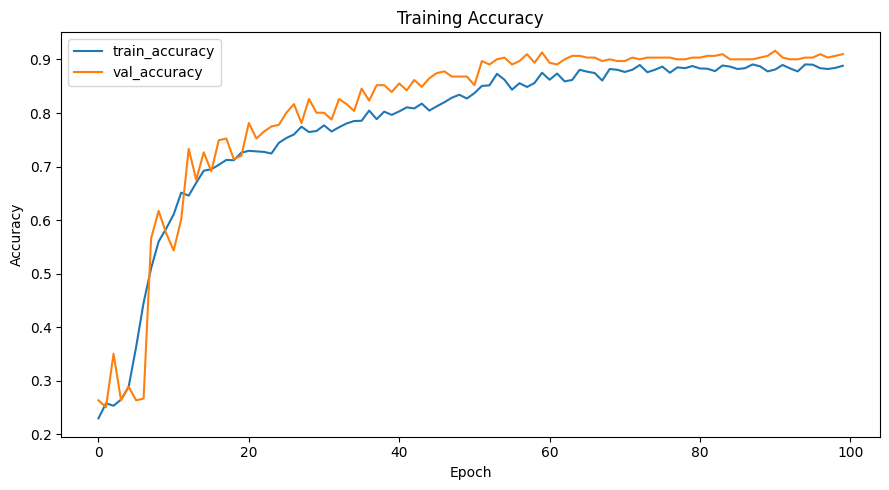

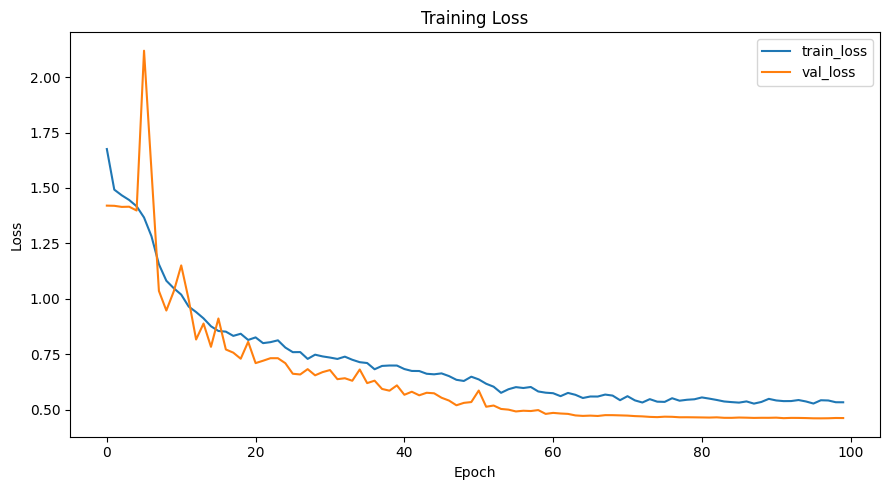


EVALUATING VALIDATION DATASET


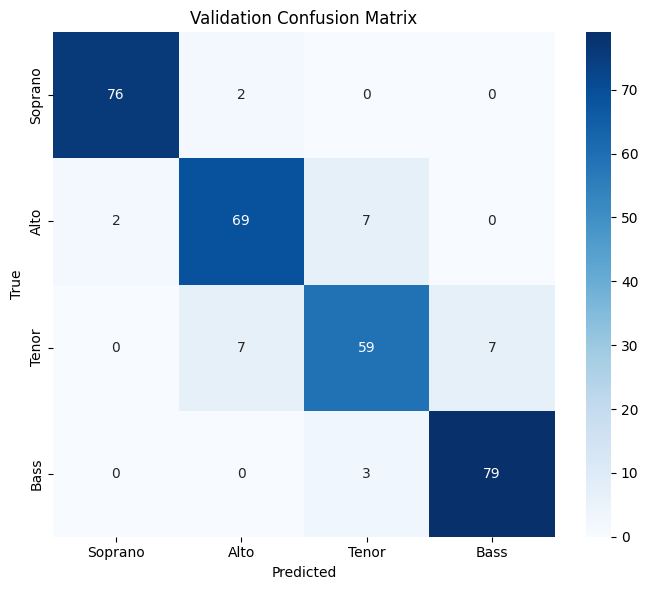

Inference time: 0.6088 seconds (1.9576 ms/sample)
{
  "status": "ok",
  "accuracy": 0.909967845659164,
  "precision_macro": 0.9081628684763163,
  "recall_macro": 0.9076520428007231,
  "f1_macro": 0.9076091162358768,
  "total_inference_time_seconds": 0.6088151590001871,
  "average_inference_time_seconds": 0.001957605012862338,
  "average_inference_time_ms": 1.9576050128623381,
  "samples_tested": 311
}
              precision    recall  f1-score   support

     Soprano       0.97      0.97      0.97        78
        Alto       0.88      0.88      0.88        78
       Tenor       0.86      0.81      0.83        73
        Bass       0.92      0.96      0.94        82

    accuracy                           0.91       311
   macro avg       0.91      0.91      0.91       311
weighted avg       0.91      0.91      0.91       311


EVALUATING INTERNAL TEST DATASET


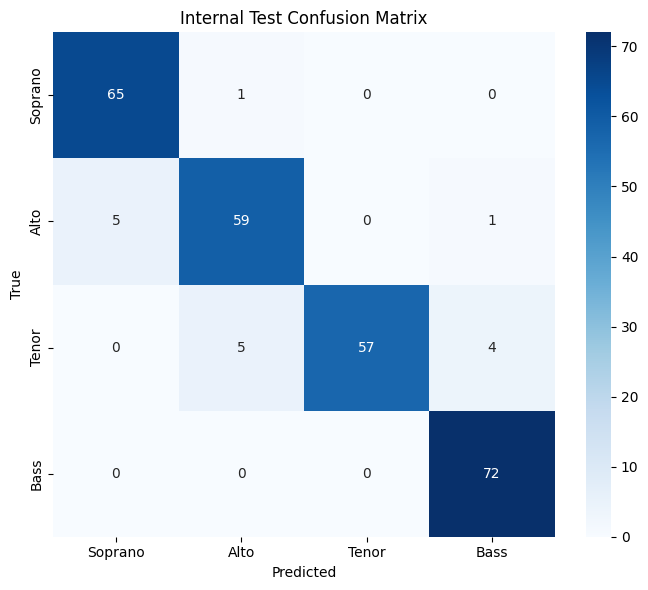

Inference time: 0.3536 seconds (1.3144 ms/sample)
{
  "status": "ok",
  "accuracy": 0.9405204460966543,
  "precision_macro": 0.9428321678321678,
  "recall_macro": 0.939044289044289,
  "f1_macro": 0.9392117204865753,
  "total_inference_time_seconds": 0.3535613750000266,
  "average_inference_time_seconds": 0.0013143545539034446,
  "average_inference_time_ms": 1.3143545539034447,
  "samples_tested": 269
}
              precision    recall  f1-score   support

     Soprano       0.93      0.98      0.96        66
        Alto       0.91      0.91      0.91        65
       Tenor       1.00      0.86      0.93        66
        Bass       0.94      1.00      0.97        72

    accuracy                           0.94       269
   macro avg       0.94      0.94      0.94       269
weighted avg       0.94      0.94      0.94       269


EVALUATING EXTERNAL TEST DATASET


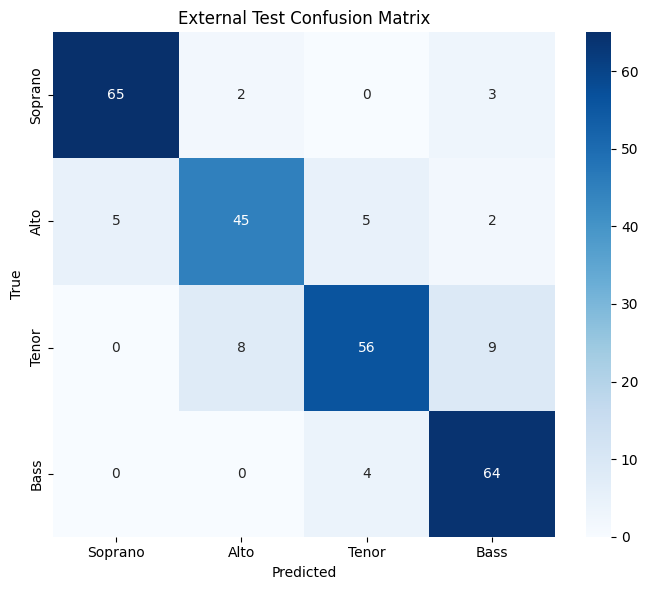

Inference time: 0.3447 seconds (1.2861 ms/sample)
{
  "status": "ok",
  "accuracy": 0.8582089552238806,
  "precision_macro": 0.8572011322011321,
  "recall_macro": 0.8565862177603558,
  "f1_macro": 0.8551123472021328,
  "total_inference_time_seconds": 0.3446724830000676,
  "average_inference_time_seconds": 0.0012860913544778642,
  "average_inference_time_ms": 1.2860913544778643,
  "samples_tested": 268
}
              precision    recall  f1-score   support

     Soprano       0.93      0.93      0.93        70
        Alto       0.82      0.79      0.80        57
       Tenor       0.86      0.77      0.81        73
        Bass       0.82      0.94      0.88        68

    accuracy                           0.86       268
   macro avg       0.86      0.86      0.86       268
weighted avg       0.86      0.86      0.86       268


PREDICTION ANALYSIS WITH SINGER & SECONDARY CLASS [VALIDATION]

--- AKURASI PER PENYANYI (SINGER-WISE ACCURACY) ---
     Singer ID  Total Sample  Correct  Ac

/tmp/ipykernel_671/3183807234.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  singer_summary = df_res.groupby("Singer ID").apply(


,Singer ID,Variation,True Class,Primary Pred (Top-1),Secondary Pred (Top-2),Status
0,S04 - kezia,R1,Soprano,Alto (51.2%),Soprano (47.1%),❌ MISMATCH
1,S04 - kezia,R1,Soprano,Alto (60.4%),Soprano (36.9%),❌ MISMATCH
2,S04 - kezia,R1,Soprano,Soprano (90.2%),Alto (3.5%),✅ MATCH
3,S04 - kezia,R1,Soprano,Soprano (94.6%),Bass (2.4%),✅ MATCH
4,S04 - kezia,R1,Soprano,Soprano (92.6%),Tenor (3.0%),✅ MATCH
5,S04 - kezia,R1,Soprano,Soprano (93.7%),Tenor (2.4%),✅ MATCH
6,S04 - kezia,R1,Soprano,Soprano (75.3%),Tenor (8.8%),✅ MATCH
7,S04 - kezia,R1,Soprano,Soprano (94.8%),Alto (3.3%),✅ MATCH
8,S04 - kezia,R2,Soprano,Soprano (81.4%),Alto (16.7%),✅ MATCH
9,S04 - kezia,R2,Soprano,Soprano (91.9%),Alto (4.6%),✅ MATCH



PREDICTION ANALYSIS WITH SINGER & SECONDARY CLASS [INTERNAL TEST]

--- AKURASI PER PENYANYI (SINGER-WISE ACCURACY) ---
        Singer ID  Total Sample  Correct  Accuracy (%)
        A06 - omk          21.0     18.0         85.71
      A12 - iffah          22.0     21.0         95.45
A16 - teman teguh          22.0     20.0         90.91
       B14 - Reyy          26.0     26.0        100.00
       B15 - Okky          22.0     22.0        100.00
       B16 - Emha          24.0     24.0        100.00
     S08 - gracel          21.0     21.0        100.00
       S12 - tasa          23.0     23.0        100.00
        S13 - tin          22.0     21.0         95.45
     T07 - julian          22.0     17.0         77.27
       T11 - fais          22.0     18.0         81.82
   T16 - Atus omk          22.0     22.0        100.00

--- PRATINJAU PREDIKSI SAMPEL (10 DATA PERTAMA) ---


/tmp/ipykernel_671/3183807234.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  singer_summary = df_res.groupby("Singer ID").apply(


,Singer ID,Variation,True Class,Primary Pred (Top-1),Secondary Pred (Top-2),Status
0,S12 - tasa,R1,Soprano,Soprano (84.9%),Alto (13.9%),✅ MATCH
1,S12 - tasa,R1,Soprano,Soprano (94.7%),Alto (4.6%),✅ MATCH
2,S12 - tasa,R1,Soprano,Soprano (93.8%),Alto (4.4%),✅ MATCH
3,S12 - tasa,R1,Soprano,Soprano (98.5%),Alto (0.7%),✅ MATCH
4,S12 - tasa,R1,Soprano,Soprano (96.5%),Alto (1.9%),✅ MATCH
5,S12 - tasa,R1,Soprano,Soprano (97.9%),Alto (1.0%),✅ MATCH
6,S12 - tasa,R1,Soprano,Soprano (97.4%),Bass (1.2%),✅ MATCH
7,S12 - tasa,R1,Soprano,Soprano (98.6%),Alto (0.8%),✅ MATCH
8,S12 - tasa,R2,Soprano,Soprano (92.5%),Alto (6.8%),✅ MATCH
9,S12 - tasa,R2,Soprano,Soprano (93.9%),Alto (4.4%),✅ MATCH



PREDICTION ANALYSIS WITH SINGER & SECONDARY CLASS [EXTERNAL TEST]

--- AKURASI PER PENYANYI (SINGER-WISE ACCURACY) ---
Singer ID  Total Sample  Correct  Accuracy (%)
      A01          14.0     13.0         92.86
      A02          14.0     14.0        100.00
      A03          13.0      7.0         53.85
      A04          16.0     11.0         68.75
      B01          14.0     12.0         85.71
      B02          12.0     11.0         91.67
      B03          14.0     14.0        100.00
      B04          14.0     14.0        100.00
      B05          14.0     13.0         92.86
      S01          14.0     14.0        100.00
      S02          14.0     14.0        100.00
      S03          14.0     12.0         85.71
      S04          14.0     13.0         92.86
      S05          14.0     12.0         85.71
      T01          13.0     13.0        100.00
      T02          15.0     12.0         80.00
      T03          16.0     12.0         75.00
      T04          14.0     13.0  

/tmp/ipykernel_671/3183807234.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  singer_summary = df_res.groupby("Singer ID").apply(


,Singer ID,Variation,True Class,Primary Pred (Top-1),Secondary Pred (Top-2),Status
0,S03,R1,Soprano,Alto (55.2%),Soprano (44.0%),❌ MISMATCH
1,S03,R1,Soprano,Alto (52.6%),Soprano (40.6%),❌ MISMATCH
2,S03,R1,Soprano,Soprano (97.2%),Alto (1.1%),✅ MATCH
3,S03,R1,Soprano,Soprano (98.0%),Alto (1.1%),✅ MATCH
4,S03,R1,Soprano,Soprano (94.3%),Tenor (2.2%),✅ MATCH
5,S03,R1,Soprano,Soprano (89.8%),Alto (6.1%),✅ MATCH
6,S03,R1,Soprano,Soprano (98.2%),Alto (1.0%),✅ MATCH
7,S03,R1,Soprano,Soprano (97.3%),Alto (1.6%),✅ MATCH
8,S03,R2,Soprano,Soprano (88.1%),Alto (10.5%),✅ MATCH
9,S03,R2,Soprano,Soprano (89.7%),Alto (8.4%),✅ MATCH



✨ Seluruh proses evaluasi dan prediksi berhasil diselesaikan!


In [43]:
import logging
import numpy as np
import pandas as pd
import tensorflow as tf

# ============================================================
# DEFINISI FUNGSI PREDIKSI DENGAN SINGER & SECONDARY CLASS
# ============================================================

def show_prediction_with_singer(X, y, metadata, dataset_name="DATASET", model_obj=None, top_n=10):
    """
    Menampilkan hasil prediksi model beserta Singer ID, Prediksi Utama (Top-1),
    dan Prediksi Sekunder (Top-2) untuk menganalisis ambiguitas kelas vokal.
    """
    if model_obj is None:
        model_obj = globals().get("model")
        if model_obj is None:
            raise ValueError("Model tidak ditemukan di global scope.")

    # 1. Dapatkan Probabilitas Prediksi
    preds_proba = model_obj.predict(X, verbose=0)

    # Sort probabilitas secara descending (Top-1 & Top-2)
    sorted_indices = np.argsort(preds_proba, axis=1)[:, ::-1]
    top1_idx = sorted_indices[:, 0]
    top2_idx = sorted_indices[:, 1]

    # Konversi y (True Label) dari One-Hot jika perlu
    if len(y.shape) > 1 and y.shape[1] > 1:
        y_true_idx = np.argmax(y, axis=1)
    else:
        y_true_idx = y

    # 2. Susun Dataframe Hasil Prediksi
    results = []
    meta_df = metadata.reset_index(drop=True)

    for i in range(len(meta_df)):
        row = meta_df.iloc[i]
        true_label = CONFIG["classes"][y_true_idx[i]]

        # Primary Prediction (Top-1)
        pred_1_label = CONFIG["classes"][top1_idx[i]]
        pred_1_conf = preds_proba[i, top1_idx[i]] * 100

        # Secondary Prediction (Top-2)
        pred_2_label = CONFIG["classes"][top2_idx[i]]
        pred_2_conf = preds_proba[i, top2_idx[i]] * 100

        is_correct = "✅ MATCH" if top1_idx[i] == y_true_idx[i] else "❌ MISMATCH"

        results.append({
            "Singer ID": row.get("singer_id", "Unknown"),
            "Variation": row.get("variation", "N/A"),
            "True Class": true_label,
            "Primary Pred (Top-1)": f"{pred_1_label} ({pred_1_conf:.1f}%)",
            "Secondary Pred (Top-2)": f"{pred_2_label} ({pred_2_conf:.1f}%)",
            "Status": is_correct
        })

    df_res = pd.DataFrame(results)

    # 3. Print Summary ke Console
    print("\n" + "=" * 75)
    print(f"PREDICTION ANALYSIS WITH SINGER & SECONDARY CLASS [{dataset_name}]")
    print("=" * 75)

    # Hitung Akurasi Per Penyanyi
    singer_summary = df_res.groupby("Singer ID").apply(
        lambda g: pd.Series({
            "Total Sample": len(g),
            "Correct": (g["Status"] == "✅ MATCH").sum(),
            "Accuracy (%)": round((g["Status"] == "✅ MATCH").mean() * 100, 2)
        })
    ).reset_index()

    print("\n--- AKURASI PER PENYANYI (SINGER-WISE ACCURACY) ---")
    print(singer_summary.to_string(index=False))

    print(f"\n--- PRATINJAU PREDIKSI SAMPEL (10 DATA PERTAMA) ---")
    display(df_res.head(top_n))

    return df_res


# ============================================================
# MAIN EVALUATION & PREDICTION PIPELINE
# ============================================================

try:
    # 1. Load Model (Disesuaikan dengan nama file tersimpan: cnn_satb.keras)
    best_model_path = PATHS["model"] / "cnn_satb.keras"
    if best_model_path.exists():
        model = tf.keras.models.load_model(best_model_path)
        logging.info("Loaded model from %s", best_model_path)
    else:
        raise FileNotFoundError(f"Model not found at {best_model_path}")

    # 2. Plot Training History (jika history_df tersedia)
    if "history_df" in globals():
        plot_training_history(history_df)

    # 3. EVALUASI KINERJA (METRICS, REPORT, CONFUSION MATRIX)
    print("\n" + "=" * 50)
    print("EVALUATING VALIDATION DATASET")
    print("=" * 50)
    mfcc_val_meta = val_meta.reset_index(drop=True)
    val_metrics = evaluate_classifier(model, X_val, y_val, mfcc_val_meta, "validation")

    print("\n" + "=" * 50)
    print("EVALUATING INTERNAL TEST DATASET")
    print("=" * 50)
    mfcc_test_meta = test_meta.reset_index(drop=True)
    internal_test_metrics = evaluate_classifier(model, X_test, y_test, mfcc_test_meta, "internal_test")

    print("\n" + "=" * 50)
    print("EVALUATING EXTERNAL TEST DATASET")
    print("=" * 50)
    mfcc_external_meta = external_meta.reset_index(drop=True)
    external_metrics = evaluate_classifier(model, X_external, y_external, mfcc_external_meta, "external_test")

    # 4. TAMPILKAN PREDIKSI UTAMA & SEKUNDER PER PENYANYI
    val_pred_df = show_prediction_with_singer(X_val, y_val, val_meta, "VALIDATION")
    test_pred_df = show_prediction_with_singer(X_test, y_test, test_meta, "INTERNAL TEST")
    ext_pred_df = show_prediction_with_singer(X_external, y_external, external_meta, "EXTERNAL TEST")

    print("\n✨ Seluruh proses evaluasi dan prediksi berhasil diselesaikan!")

except Exception as stage_exc:
    logging.exception("Evaluation and prediction stage failed.")
    raise RuntimeError(f"Evaluation and prediction failed: {stage_exc}") from stage_exc


MODEL PERFORMANCE COMPARISON


,Dataset,Accuracy,Precision,Recall,F1-Score
0,Validation,91.00%,90.82%,90.77%,90.76%
1,Internal Test,94.05%,94.28%,93.90%,93.92%
2,External Test,85.82%,85.72%,85.66%,85.51%


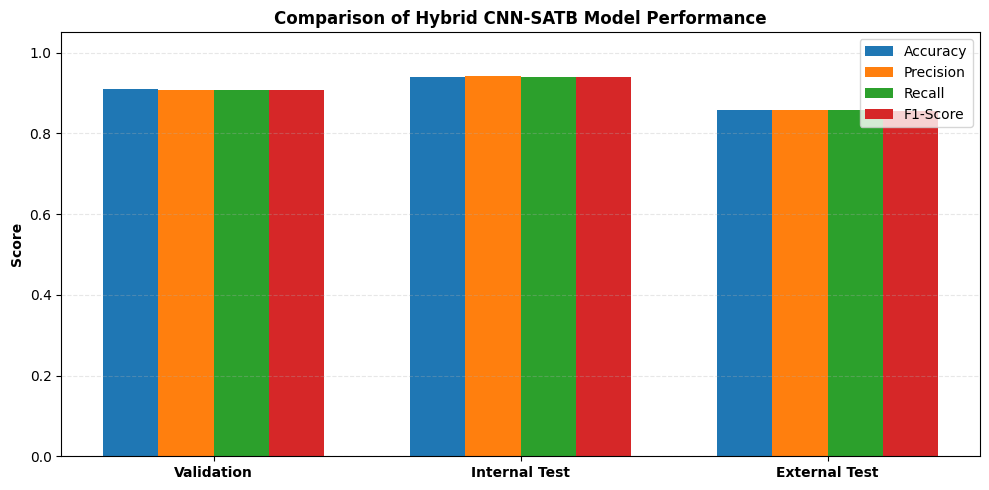

In [44]:
# ============================================================
# COMPARE VALIDATION, INTERNAL TEST, EXTERNAL TEST
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_dataset(model, X, y, name):
    pred = model.predict(X, verbose=0)

    y_true = np.argmax(y, axis=1)
    y_pred = np.argmax(pred, axis=1)

    return {
        "Dataset": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    }

results = []

results.append(
    evaluate_dataset(
        model,
        X_val,
        y_val,
        "Validation"
    )
)

results.append(
    evaluate_dataset(
        model,
        X_test,
        y_test,
        "Internal Test"
    )
)

results.append(
    evaluate_dataset(
        model,
        X_external,
        y_external,
        "External Test"
    )
)

comparison_df = pd.DataFrame(results)

print("\nMODEL PERFORMANCE COMPARISON")
print("=" * 70)

display(
    comparison_df.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1-Score": "{:.2%}"
    })
)

# ============================================================
# VISUALIZATION
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

x = np.arange(len(comparison_df["Dataset"]))
width = 0.18

plt.figure(figsize=(10, 5))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        comparison_df[metric],
        width,
        label=metric
    )

plt.xticks(
    x,
    comparison_df["Dataset"],
    fontweight="bold"
)

plt.ylabel("Score", fontweight="bold")
plt.title(
    "Comparison of Hybrid CNN-SATB Model Performance",
    fontweight="bold",
    fontsize=12
)

plt.ylim(0, 1.05)

plt.legend(frameon=True)
plt.grid(
    axis="y",
    alpha=0.3,
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# DAFTAR PENYANYI PER KELAS + JUMLAH
# ============================================================

from pathlib import Path

print("="*50)
print("DAFTAR PENYANYI")
print("="*50)

all_singers = set()

for cls in CONFIG["classes"]:

    files = audio_metadata_df[
        audio_metadata_df["class_name"] == cls
    ]["file_path"]

    singers = set()

    for file in files:
        parts = Path(file).parts

        # ambil folder penyanyi
        # contoh:
        # .../Soprano/S01/R1.wav
        # hasil: S01
        if len(parts) >= 2:
            singers.add(parts[-2])

    singers = sorted(singers)

    all_singers.update(singers)

    print(f"\n{cls} ({len(singers)} penyanyi):")

    for i, singer in enumerate(singers, start=1):
        print(f"{i}. {singer}")


print("\n" + "="*50)
print(f"TOTAL PENYANYI: {len(all_singers)}")
print("="*50)

DAFTAR PENYANYI

Soprano (21 penyanyi):
1. S01
2. S01 - nata
3. S02
4. S02 - marcia
5. S03
6. S03 - tasya
7. S04
8. S04 - kezia
9. S05
10. S05 - mariata
11. S06 - Dewingga
12. S07 - Nanes
13. S08 - gracel
14. S09 - coach Tania 
15. S10 - kurnia
16. S11 - Mersya
17. S12 - tasa
18. S13 - tin
19. S14 - naya
20. S15 - Febri
21. S16 - Dethryc

Alto (20 penyanyi):
1. A01
2. A01 - Kak Kulla
3. A02
4. A02 - Kak Tiara
5. A03
6. A03 - Naim
7. A04
8. A04 - Uut
9. A05 - Figur
10. A06 - omk
11. A07 - sartika
12. A08 - nabila
13. A09 - kk marya
14. A10 - joy
15. A11 - yaya
16. A12 - iffah
17. A13 - kk tania
18. A14 - insy
19. A15 - suri
20. A16 - teman teguh

Tenor (21 penyanyi):
1. T01
2. T01 - aidil
3. T02
4. T02 - dewa
5. T03
6. T03 - caya
7. T04
8. T04 - zaky
9. T05
10. T05 - esau
11. T06 - Calvin 
12. T07 - julian
13. T08 - reno
14. T09 - omk
15. T10 - Syifaiz
16. T11 - fais
17. T12 - Ernest
18. T13 - Ilham
19. T14 - teman teguh
20. T15 - Agung
21. T16 - Atus omk

Bass (20 penyanyi):
1. B01
2. 

# 15. Save Model

Bagian ini menyimpan model akhir dalam format `.keras`, label mapping, dan konfigurasi eksperimen. Model terbaik selama training juga sudah disimpan melalui `ModelCheckpoint`.


In [46]:
try:
    final_model_path = PATHS["model"] / "cnn_satb.keras"
    model.save(final_model_path)

    label_mapping = {
        "label_to_index": LABEL_TO_INDEX,
        "index_to_label": {str(k): v for k, v in INDEX_TO_LABEL.items()},
        "target_frames": int(target_frames),
        "input_shape": list(X_train.shape[1:]),
    }
    with open(PATHS["model"] / "label_mapping.json", "w", encoding="utf-8") as f:
        json.dump(label_mapping, f, indent=2)

    serializable_config = {
        key: str(value) if isinstance(value, Path) else value
        for key, value in CONFIG.items()
    }
    with open(PATHS["model"] / "experiment_config.json", "w", encoding="utf-8") as f:
        json.dump(serializable_config, f, indent=2)

    logging.info("Final model saved: %s", final_model_path)
    print(f"Final model saved to: {final_model_path}")
    print(f"Best checkpoint: {PATHS['model'] / 'cnn_satb_best.keras'}")
except Exception as stage_exc:
    logging.exception("Save model stage failed.")
    raise RuntimeError(f"Save model failed: {stage_exc}") from stage_exc


2026-09-15 12:58:17,963 | INFO | Final model saved: /content/drive/MyDrive/SATB_Model/Model/cnn_satb.keras
Final model saved to: /content/drive/MyDrive/SATB_Model/Model/cnn_satb.keras
Best checkpoint: /content/drive/MyDrive/SATB_Model/Model/cnn_satb_best.keras


# 16. Final Summary

Bagian ini menampilkan ringkasan akhir artefak yang dihasilkan: cleaned dataset, metadata, augmented dataset, tensor MFCC, model CNN, metrik evaluasi internal, metrik external test, plot, dan log file. Jika ada subset yang kosong akibat keterbatasan jumlah penyanyi, informasi tersebut tetap dicatat di log dan ringkasan.


In [47]:
try:
    produced_files = {
        "metadata_validation": PATHS["metadata"] / "metadata_validation.csv",
        "metadata_dataset": PATHS["metadata"] / "metadata_dataset.csv",
        "metadata_reconstruction": PATHS["metadata"] / "metadata_reconstruction.csv",
        "metadata_preprocessing": PATHS["metadata"] / "metadata_preprocessing.csv",
        "metadata_audio": PATHS["metadata"] / "metadata_audio.csv",
        "metadata_split": PATHS["metadata"] / "metadata_split.csv",
        "metadata_augmentation": PATHS["metadata"] / "metadata_augmentation.csv",
        "metadata_mfcc": PATHS["metadata"] / "metadata_mfcc.csv",
        "mfcc_tensors": PATHS["result"] / "mfcc_tensors.npz",
        "training_history": PATHS["result"] / "training_history.csv",
        "best_model": PATHS["model"] / "cnn_satb_best.keras",
        "final_model": PATHS["model"] / "cnn_satb.keras",
        "history_pickle": PATHS["model"] / "history.pkl",
        "accuracy_plot": PATHS["result"] / "accuracy.png",
        "loss_plot": PATHS["result"] / "loss.png",
        "confusion_matrix_plot": PATHS["result"] / "confusion_matrix.png",
        "classification_report": PATHS["result"] / "classification_report.csv",
        "external_test_csv": PATHS["result"] / "external_test.csv",
        "internal_metrics": PATHS["result"] / "internal_test_metrics.json",
        "external_metrics": PATHS["result"] / "external_test_metrics.json",
        "log_file": PATHS["logs"] / "pipeline.log",
    }

    summary_rows = []
    for name, path in produced_files.items():
        summary_rows.append({"artifact": name, "path": str(path), "exists": path.exists()})
    summary_df = pd.DataFrame(summary_rows)

    print("Pipeline completed.")
    print("Internal test metrics:", internal_test_metrics)
    print("External test metrics:", external_metrics)
    display(summary_df)

    print("\nChecklist final output:")
    print("✔ cleaned dataset:", PATHS["processed"].exists())
    print("✔ metadata:", PATHS["metadata"].exists())
    print("✔ augmented dataset:", PATHS["augmented"].exists())
    print("✔ MFCC tensors:", (PATHS["result"] / "mfcc_tensors.npz").exists())
    print("✔ trained CNN model:", (PATHS["model"] / "cnn_satb.keras").exists())
    print("✔ evaluation metrics:", (PATHS["result"] / "internal_test_metrics.json").exists())
    print("✔ external test metrics:", (PATHS["result"] / "external_test_metrics.json").exists())
    print("✔ saved model (.keras):", (PATHS["model"] / "cnn_satb.keras").exists())
    print("✔ plots:", PATHS["result"].exists())
    print("✔ log file:", (PATHS["logs"] / "pipeline.log").exists())
except Exception as stage_exc:
    logging.exception("Final summary stage failed.")
    raise RuntimeError(f"Final summary failed: {stage_exc}") from stage_exc


Pipeline completed.
Internal test metrics: {'status': 'ok', 'accuracy': 0.9405204460966543, 'precision_macro': 0.9428321678321678, 'recall_macro': 0.939044289044289, 'f1_macro': 0.9392117204865753, 'total_inference_time_seconds': 0.3535613750000266, 'average_inference_time_seconds': 0.0013143545539034446, 'average_inference_time_ms': 1.3143545539034447, 'samples_tested': 269}
External test metrics: {'status': 'ok', 'accuracy': 0.8582089552238806, 'precision_macro': 0.8572011322011321, 'recall_macro': 0.8565862177603558, 'f1_macro': 0.8551123472021328, 'total_inference_time_seconds': 0.3446724830000676, 'average_inference_time_seconds': 0.0012860913544778642, 'average_inference_time_ms': 1.2860913544778643, 'samples_tested': 268}


,artifact,path,exists
0,metadata_validation,/content/drive/MyDrive/SATB_Model/Dataset/Meta...,True
1,metadata_dataset,/content/drive/MyDrive/SATB_Model/Dataset/Meta...,True
2,metadata_reconstruction,/content/drive/MyDrive/SATB_Model/Dataset/Meta...,False
3,metadata_preprocessing,/content/drive/MyDrive/SATB_Model/Dataset/Meta...,True
4,metadata_audio,/content/drive/MyDrive/SATB_Model/Dataset/Meta...,True
5,metadata_split,/content/drive/MyDrive/SATB_Model/Dataset/Meta...,True
6,metadata_augmentation,/content/drive/MyDrive/SATB_Model/Dataset/Meta...,True
7,metadata_mfcc,/content/drive/MyDrive/SATB_Model/Dataset/Meta...,False
8,mfcc_tensors,/content/drive/MyDrive/SATB_Model/Result/mfcc_...,True
9,training_history,/content/drive/MyDrive/SATB_Model/Result/train...,True



Checklist final output:
✔ cleaned dataset: True
✔ metadata: True
✔ augmented dataset: True
✔ MFCC tensors: True
✔ trained CNN model: True
✔ evaluation metrics: True
✔ external test metrics: True
✔ saved model (.keras): True
✔ plots: True
✔ log file: True


# 17. Demo Implementasi Model

Bagian ini memuat model terbaik yang telah disimpan dan digunakan untuk melakukan prediksi pada data audio baru. Tahapan yang dilakukan meliputi pemuatan model, preprocessing audio, ekstraksi fitur MFCC, dan klasifikasi jenis suara paduan suara berdasarkan hasil prediksi model.

In [56]:
# ============================================================
# DEMO KLASIFIKASI JENIS SUARA PADUAN SUARA
# ============================================================

from pathlib import Path
from google.colab import files
from IPython.display import Audio, display
import json, librosa, noisereduce as nr
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# CONFIG
MODEL_PATH = "/content/drive/MyDrive/SATB_Model/Model/cnn_satb.keras"
META_PATH = "/content/drive/MyDrive/SATB_Model/Model/model_metadata.json"
SR, TRIM_DB = 16000, 25
N_MFCC, N_FFT, HOP = 40, 2048, 512

# LOAD MODEL
model = tf.keras.models.load_model(MODEL_PATH)
with open(META_PATH) as f:
    meta = json.load(f)

LABELS = {int(k): v for k, v in meta["index_to_label"].items()}
TARGET = int(meta["target_frames"])
MEAN, STD = float(meta["mean"]), float(meta["std"])

print("=" * 60)
print("DEMO KLASIFIKASI JENIS SUARA PADUAN SUARA")
print("=" * 60)
print("Model loaded :", MODEL_PATH)
print("Classes      :", list(LABELS.values()))

# PREPROCESSING + FEATURE EXTRACTION
def extract_features(path):
    audio, _ = librosa.load(path, sr=SR, mono=True)
    audio = nr.reduce_noise(y=audio, sr=SR, n_jobs=1)
    audio, _ = librosa.effects.trim(audio, top_db=TRIM_DB)
    if len(audio) == 0: raise ValueError("Audio kosong.")

    peak = np.max(np.abs(audio))
    if peak > 0: audio /= peak

    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC,
                                n_fft=N_FFT, hop_length=HOP, window="hann")
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    chroma = librosa.feature.chroma_stft(y=audio, sr=SR,
                                         n_fft=N_FFT, hop_length=HOP)
    chroma = np.mean(chroma, axis=0, keepdims=True)
    chroma = np.pad(chroma, ((0, N_MFCC - 1), (0, 0)), mode="edge")

    feat = np.stack([mfcc, delta, delta2, chroma], axis=-1).astype(np.float32)

    if feat.shape[1] < TARGET:
        feat = np.pad(feat, ((0, 0), (0, TARGET - feat.shape[1]), (0, 0)))
    else:
        feat = feat[:, :TARGET, :]

    feat = (feat - MEAN) / (STD + 1e-8)
    return np.expand_dims(feat.astype(np.float32), axis=0)

# UPLOAD
print("\nUpload file audio yang ingin diuji:")
uploaded = files.upload()

results, all_probs = [], []

# PREDIKSI
for filename in uploaded:
    print("\n" + "=" * 60)
    print(f"FILE: {filename}")
    print("=" * 60)
    display(Audio(filename))

    try:
        probs = model.predict(extract_features(filename), verbose=0)[0]
        idx = int(np.argmax(probs))
        pred, conf = LABELS[idx], float(probs[idx])
        all_probs.append(probs)

        row = {"File": filename, "Prediksi": pred, "Confidence": f"{conf:.2%}"}
        row.update({LABELS[i]: f"{probs[i]:.2%}" for i in LABELS})
        results.append(row)

        print(f"Prediksi   : {pred}")
        print(f"Confidence : {conf:.2%}")
    except Exception as e:
        print("Error:", e)

# HASIL
if results:
    print("\n" + "=" * 60)
    print("HASIL PREDIKSI SETIAP FILE")
    print("=" * 60)
    display(pd.DataFrame(results))

    mean_probs = np.mean(all_probs, axis=0)
    final_idx = int(np.argmax(mean_probs))

    print("\n" + "=" * 60)
    print("HASIL AGREGASI")
    print("=" * 60)
    print(f"Jumlah file     : {len(results)}")
    print(f"Prediksi akhir  : {LABELS[final_idx]}")
    print(f"Confidence akhir: {mean_probs[final_idx]:.2%}")

    # PROBABILITAS
    prob_df = pd.DataFrame({
        "Jenis Suara": [LABELS[i] for i in LABELS],
        "Probabilitas": [f"{mean_probs[i]:.2%}" for i in LABELS]
    })

    print("\n" + "=" * 60)
    print("PROBABILITAS RATA-RATA")
    print("=" * 60)
    display(prob_df)

    # GRAFIK
    plt.figure(figsize=(8, 4))
    bars = plt.bar([LABELS[i] for i in LABELS], mean_probs)
    plt.title("Probabilitas Rata-rata Klasifikasi")
    plt.xlabel("Jenis Suara")
    plt.ylabel("Probabilitas")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.2)

    for bar, value in zip(bars, mean_probs):
        plt.text(bar.get_x() + bar.get_width()/2, value + 0.02,
                 f"{value:.2%}", ha="center")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.